In [1]:
import os, sys, warnings

import earthaccess
from osgeo import gdal

import pandas as pd
import numpy as np
import xarray as xr
import math
import glob

import rasterio as rio

import netCDF4 as nc
from datetime import datetime, timedelta, timezone

from scipy import ndimage as ndi
from scipy.ndimage import binary_fill_holes, center_of_mass, distance_transform_edt
from scipy.interpolate import PchipInterpolator  # monotone, shape-preserving

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy import linalg
from scipy.signal import savgol_filter
import scipy.ndimage as ndi
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation, rotate, shift
from skimage.transform import hough_line, hough_line_peaks
from skimage.restoration import (
    denoise_tv_chambolle,
    denoise_bilateral,
    denoise_wavelet,
    estimate_sigma,
    inpaint_biharmonic
)

# This will ignore some warnings caused by holoviews
warnings.simplefilter('ignore') 

sys.path.append('../../EMIT-Data-Resources/python/modules/')
from emit_tools import emit_xarray, ortho_xr

sys.path.append('../')
from config import *
from REFERENCE_PLANTS import REFERENCE_PLANTS

sys.path.append('../../datasets/')
import get_geosfp
import get_campd
import amf_compute
import importlib


# Reload the module
importlib.reload(get_campd)
importlib.reload(get_geosfp)
importlib.reload(amf_compute)

get_emission_rate = get_campd.get_emission_rate
get_emissions = get_campd.get_emissions

get_geosfp_wind = get_geosfp.get_geosfp_wind
get_geosfp_tph = get_geosfp.get_geosfp_tph

PREFIXES = {'OBS': 'EMIT_L1B_OBS_001_',
 'L1B': 'EMIT_L1B_RAD_001_',
 'MASK': 'EMIT_L2A_MASK_001_',
 'L2A': 'EMIT_L2A_RFL_001_'}

help(emit_xarray)

Help on function emit_xarray in module emit_tools:

emit_xarray(filepath, ortho=False, qmask=None, unpacked_bmask=None)
    This function utilizes other functions in this module to streamline opening an EMIT dataset as an xarray.Dataset.
    
    Parameters:
    filepath: a filepath to an EMIT netCDF file
    ortho: True or False, whether to orthorectify the dataset or leave in crosstrack/downtrack coordinates.
    qmask: a numpy array output from the quality_mask function used to mask pixels based on quality flags selected in that function. Any non-orthorectified array with the proper crosstrack and downtrack dimensions can also be used.
    unpacked_bmask: a numpy array from  the band_mask function that can be used to mask band-specific pixels that have been interpolated.
    
    Returns:
    out_xr: an xarray.Dataset constructed based on the parameters provided.



In [2]:
CONFIG

{'data_folder': '/orcd/data/dvaron/001/kgauld/EMIT/data',
 'results_folder': '/orcd/data/dvaron/001/kgauld/EMIT/results6_destriped',
 'plot_folder': '/orcd/data/dvaron/001/kgauld/EMIT/plots6_destriped_recolor',
 'geosfp': '/orcd/data/dvaron/001/kgauld/GEOS_FP',
 'hrrr': '/orcd/data/dvaron/001/kgauld/HRRR',
 'tropomi': '/orcd/data/dvaron/001/kgauld/TROPOMI',
 'campd_key': '/orcd/pool/005/dvaron_shared/kgauld/emit-nox-plumes/secrets/CAMPD_APIKEY',
 'retr_subdir': 'Retrievals',
 'tavg_subdir': 'Time_Average',
 'ps_subdir': 'Point_Source',
 'NOX_CSEC': '/orcd/home/002/kgauld/emit-nox-plumes/cross_sections/no2c_97.txt',
 'AMF_LUT': '/orcd/data/dvaron/001/kgauld/AMF/differential_amf.nc'}

In [3]:
csv_savefn = f"{CONFIG['data_folder']}/metadata_FULL.csv"
data = pd.read_csv(csv_savefn)
data

FileNotFoundError: [Errno 2] No such file or directory: '/orcd/data/dvaron/001/kgauld/EMIT/data/metadata_FULL.csv'

In [4]:
# class_data = pd.read_csv('class_6_destripe_rc.csv')
# len(class_data.loc[class_data['plume'], 'granule'])

In [5]:
class_savefn = 'class_6_destripe_rc.csv'#'classifications_plots6.csv'
class_data = pd.read_csv(class_savefn)
class_data

# class_data['granule'=='']

,loc_name,granule,out_of_bounds,cloudy,plume,no_plume,unquantifiable
0,Alcoa_Allowance_Management_Inc,20240201T174028_2403212_025,False,True,False,False,False
1,Alcoa_Allowance_Management_Inc,20240205T160545_2403611_026,False,False,False,True,False
2,Alcoa_Allowance_Management_Inc,20240326T201420_2408613_023,False,False,False,True,False
3,Alcoa_Allowance_Management_Inc,20240425T152333_2411610_005,False,False,False,True,False
4,Alcoa_Allowance_Management_Inc,20240627T143027_2417910_002,False,False,True,False,False
...,...,...,...,...,...,...,...
292,Labadie,20241001T174402_2427512_016,False,False,False,True,False
293,Labadie,20251004T160336_2527710_026,False,False,True,False,False
294,Colstrip,20250608T164919_2515911_022,False,False,True,False,False
295,Labadie,20250724T203011_2520513_024,False,False,True,False,False


In [6]:
len(class_data.loc[class_data['plume'], 'granule'])

73

In [7]:
hasplume_data = data[data['GRANULE'].isin(class_data.loc[class_data['plume'], 'granule'])]
print(f"{len(hasplume_data)=}")
# hasplume_data

len(hasplume_data)=73


In [8]:
# relabel = '20251001T165151_2527410_030'
# hasplume = False

# class_data.loc[class_data['granule']==relabel, 'no_plume'] = not hasplume
# class_data.loc[class_data['granule']==relabel, 'plume'] = hasplume

# class_data[class_data['granule']==relabel]

In [9]:
np.unique(hasplume_data['LOC_NAME'])

array(['Alcoa_Allowance_Management_Inc', 'Colstrip',
       'Fort_Martin_Power_Station', 'Gerald_Gentleman_Station', 'Ghent',
       'Intermountain', 'Labadie', 'Laramie_River', 'Limestone',
       'Martin_Lake', 'Mill_Creek', 'New_Madrid_Power_Plant',
       'Ninemile_Point', 'Scherer', 'Shawnee',
       'Thomas_Hill_Energy_Center', 'W_A_Parish'], dtype=object)

In [10]:
# CONFIG['results_folder']= '/orcd/data/dvaron/001/kgauld/EMIT/results6'

In [11]:
# maybe_ignore = {
#     'Fort_Martin_Power_Station': ['20240621T160640_2417311_031'], # super cloudy
#     'Gerald_Gentleman_Station': ['20230423T173615_2311312_010'], # maybe not great
#     'Ghent': ['20250625T142646_2517609_004'], # leaves scene
# }

# skipped = {
#     'Ghent': ['20240805T155734_2421811_028']# leaves scene, skipped
# }

# skipped = {
#     'Ghent': ['20251001T165151_2527410_030'] # mark as nondetect
# }

noplumes = []

done = ['Alcoa_Allowance_Management_Inc', 'Colstrip', 'Ninemile_Point', 'Fort_Martin_Power_Station', 'Colstrip', 
        'Scherer', 'Shawnee', 'New_Madrid_Power_Plant', 'Thomas_Hill_Energy_Center', 'W_A_Parish', 'Mill_Creek',
        'Martin_Lake','Limestone', 'Ghent', 'Gerald_Gentleman_Station', 'Laramie_River', 'Labadie']

ignore = {
    'New_Madrid_Power_Plant': [
        '20240815T191458_2422813_045' # Mask in the way-can't reliably form plume mask
    ], 
    'Fort_Martin_Power_Station': [
        '20240621T160640_2417311_031' # Cloud in the near-plume, heavy underestimate
    ], 
    'Colstrip': [
        '20250407T172525_2509711_006', # Suspicious wind speed
        '20250213T190437_2504413_005'  # Huge AMF
    ],
    'Alcoa_Allowance_Management_Inc': [
        '20251128T175548_2533211_026', # Really faint plume
        '20250816T180256_2522812_036' # REALLY low wind, prediction very wrong
    ], 
    'Scherer': [
        '20250620T165405_2517111_039' # cloudy + faint
    ],
    'Mill_Creek': [
        '20231002T175056_2327512_007' # Leaves scene
    ],
    'Ghent': [
        '20240805T155734_2421811_028' # Leaves scene
    ],
    'Gerald_Gentleman_Station' : [
        '20230216T194354_2304713_010', # Leaves scene, High AMF, but accurate pred
        '20250619T173827_2517011_024' # Near plume blocked
    ],
    'Laramie_River': [
        '20230728T214448_2320914_018', # Leaves scene, but extremely accurate
        '20250805T171219_2521711_022' # Leaves scene RLY fast, def remove
    ],
    'Labadie': [
        '20240808T150901_2422110_002', # Generally suspicious shape
        '20231001T183836_2327412_016', # leaves scene
        '20250624T151429_2517510_011', # mask issue 
        '20251004T160336_2527710_026' # p sure not actually a plume
    ],
    'Intermountain': [
        '20250609T222850_2516014_017', # rly faint
        '20240212T214534_2404314_009', # snowy
        '20230927T214729_2327014_012', # probs nondetect
        '20230202T193710_2303313_007', # snowy
    ]
}

skipped = {
    'Colstrip': ['20240811T204736_2422414_021'], # too cloudy
    'Labadie': ['20250724T203011_2520513_024'], # Most def not a plume lol]
    'Intermountain': ['20250816T193520_2522813_017',] # too cloudy
}

In [12]:
[c if c not in done else None for c in np.unique(hasplume_data['LOC_NAME'])]

[None,
 None,
 None,
 None,
 None,
 'Intermountain',
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [13]:
retrieval_log_fn = f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/source_retr_data.csv"
retr_log = pd.read_csv(retrieval_log_fn) 

loc_name = 'Alcoa_Allowance_Management_Inc'
retr_log[retr_log['LOC_NAME']==loc_name]

,LOC_NAME,GRANULE,CAMPD,SMOOTHED,BINNED,MEAN,AMF
20,Alcoa_Allowance_Management_Inc,20251128T175548_2533211_026,0.155554,0.120993,0.123258,0.077392,1.145369
21,Alcoa_Allowance_Management_Inc,20250816T180256_2522812_036,0.233461,0.045486,0.044310,0.031721,1.101745
22,Alcoa_Allowance_Management_Inc,20240627T143027_2417910_002,0.122104,0.323779,0.341658,0.238950,0.763557
23,Alcoa_Allowance_Management_Inc,20250609T205631_2516013_034,0.109209,0.346520,0.345655,0.186094,0.846724
24,Alcoa_Allowance_Management_Inc,20250927T182624_2527011_027,0.066284,0.204504,0.189785,0.118054,0.915450


In [14]:
data_for_loc = data[data['LOC_NAME'] == loc_name]
work_loc_data = hasplume_data[data['LOC_NAME'] == loc_name]
granules = work_loc_data['GRANULE'].values
for i, g in enumerate(granules):
    print(f'{i}\t{g}')

0	20251128T175548_2533211_026
1	20250609T205631_2516013_034
2	20250816T180256_2522812_036
3	20240627T143027_2417910_002
4	20250927T182624_2527011_027


413_013 NO
314_009 NO
313_007 YES BUT SNOWY

13    20250816T193520_2522813_017 NO
21    20250820T175830_2523212_017 NO
23    20250420T182035_2511012_017 YES

In [20]:
granule_name = granules[1]
granule_data = data[data['GRANULE'] == granule_name]
fp_mask = f"{CONFIG['data_folder']}/{loc_name}/{PREFIXES['MASK']}{granule_name}.nc"

print(f"LOC_NAME: {loc_name}\nGRANULE: {granule_name}")
# print(f"{fp_mask=}")

loc_type = 'plant'

if loc_type == 'plant':
    loc_data = REFERENCE_PLANTS[loc_name]
else:
    loc_data = LOCS[loc_name]

retrieval_fpath = f"{CONFIG['results_folder']}/{CONFIG['retr_subdir']}/{loc_name}/dSCD_{PREFIXES['L1B']}{granule_name}.npy"
radiance_fpath = f"{CONFIG['data_folder']}/{loc_name}/{PREFIXES['L1B']}{granule_name}.nc"

obs_time = datetime.strptime(granule_name.split('_')[0], "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)

# campd_e_rate = get_emission_rate(loc_data, obs_time, timedelta(hours=4))
campd_e_rate = granule_data["CAMPD_RATE"].values[0]
print(f"campd emission rate for 4 hours prior: {campd_e_rate:0.2f} kg/s")

mean_windspeed = granule_data[["GEOSFP_50M_SPD", "HRRR_10M_SPD", "HRRR_AGL_SPD"]].iloc[0].mean()
print(f"mean wind speed {mean_windspeed:0.2f} m/s")
geosfp_info = get_geosfp_wind(loc_data['LAT'], loc_data['LON'], obs_time, cache=f'{CONFIG["geosfp"]}/')
geosfp_info

LOC_NAME: Alcoa_Allowance_Management_Inc
GRANULE: 20250609T205631_2516013_034
campd emission rate for 4 hours prior: 0.11 kg/s
mean wind speed 3.47 m/s


{'PS': 993.3565625,
 'T2M': 297.9852600097656,
 'U2': 2.278814424868354,
 'DIR2': 278.9080699118973,
 'U10': 3.262805940035035,
 'DIR10': 278.89540812336605,
 'U50': 4.13767521626146,
 'DIR50': 279.29053717551443,
 'U500_log': 5.50457450529412,
 'U500_power': 6.504191970340709,
 'z0_fit': 0.04042526993079622,
 'alpha': 0.14759596709932787,
 'log_law': <function get_geosfp.get_geosfp_wind.<locals>.<lambda>(z)>,
 'power_law': <function get_geosfp.get_geosfp_wind.<locals>.<lambda>(z)>,
 'surface_pressure_Pa': 99335.65625}

In [21]:
granule_data['HRRR_AGL_SPD']

6    3.605462
Name: HRRR_AGL_SPD, dtype: float64

In [22]:
# Colstrip 20250213T190437_2504413_005

Completed orthorectification


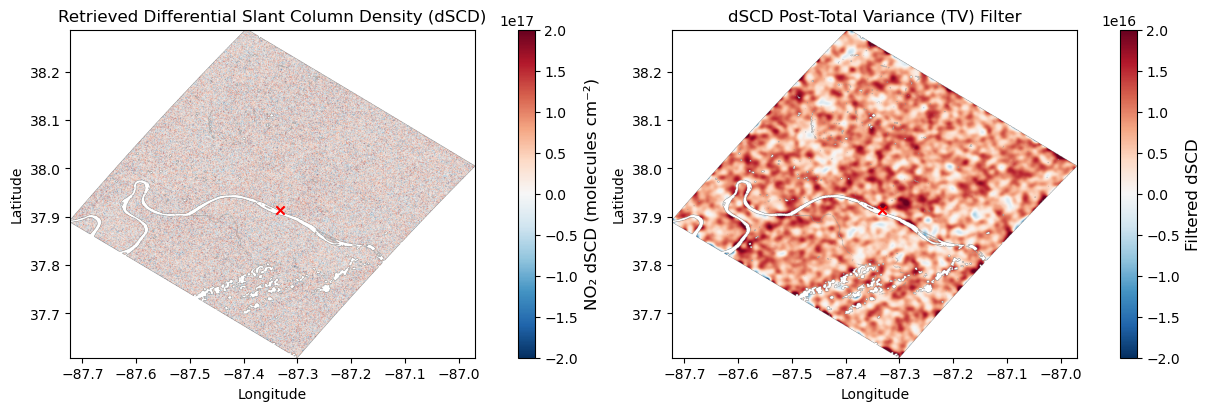

In [24]:
ds_no_orth = emit_xarray(radiance_fpath, ortho=False)
retrieval = np.load(retrieval_fpath)

dSCD = np.load(retrieval_fpath)
ds_no_orth = emit_xarray(radiance_fpath)

wl_val = float(ds_no_orth["wavelengths"].isel(wavelengths=0))  # or a specific value
dscd_da = xr.DataArray(
    dSCD.astype('float32')[..., None],  # -> (downtrack, crosstrack, 1)
    dims=("downtrack", "crosstrack", "wavelengths"),
    coords={
        "downtrack": ds_no_orth["downtrack"],
        "crosstrack": ds_no_orth["crosstrack"],
        "wavelengths": [wl_val],
    },
    name="dSCD",
    attrs={
        "long_name": "Differential Slant Column Density (single band)",
        "units": "molec cm^-2",
    },
)
ds_no_orth = ds_no_orth.assign(dSCD=dscd_da)
ds = ortho_xr(ds_no_orth)

(dy, dx) = ds.rio.resolution() # in deg
pix_pitch_m = 111000 * abs(dy)

del ds_no_orth

bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))

# axs[i].imshow(ds['radiance'][:,:,0], cmap='gray', extent=bounds)
rad1500 = ds['radiance'].sel(wavelengths=1500, method='nearest').values
dSCD_nan = np.where(rad1500 <= -8000, np.nan, ds['dSCD'].values[:,:,0])*1e19

valid_lat = ds['latitude'].values[np.where(~np.isnan(dSCD_nan))[0]]
valid_lon = ds['longitude'].values[np.where(~np.isnan(dSCD_nan))[1]]

latmin_bnd, latmax_bnd = valid_lat.min(), valid_lat.max()
lonmin_bnd, lonmax_bnd = valid_lon.min(), valid_lon.max()

print(f"Completed orthorectification")

mask = np.isfinite(dSCD_nan)

_, idx = distance_transform_edt(~mask, return_indices=True)
filled = dSCD_nan[tuple(idx)]/1e19   # copies nearest valid value into each NaN pixel

tv = denoise_tv_chambolle(filled, weight=0.2)
tv[~mask] = np.nan


fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4), layout='constrained')

im = ax[0].imshow(dSCD_nan, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds)
cb = plt.colorbar(im, ax=ax[0])
cb.set_label("NO₂ dSCD (molecules cm⁻²)", fontsize=12)
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
ax[0].set_title('Retrieved Differential Slant Column Density (dSCD)')

im = ax[1].imshow(tv*1e19, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-2e16, vmax=2e16, extent=bounds)
cb = plt.colorbar(im, ax=ax[1])
cb.set_label("Filtered dSCD", fontsize=12)
ax[1].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')
ax[1].set_title('dSCD Post-Total Variance (TV) Filter')

for a in ax:
    a.set_xlim(lonmin_bnd, lonmax_bnd)
    a.set_ylim(latmin_bnd, latmax_bnd)

    a.set_ylabel('Latitude')
    a.set_xlabel('Longitude')

plt.show()

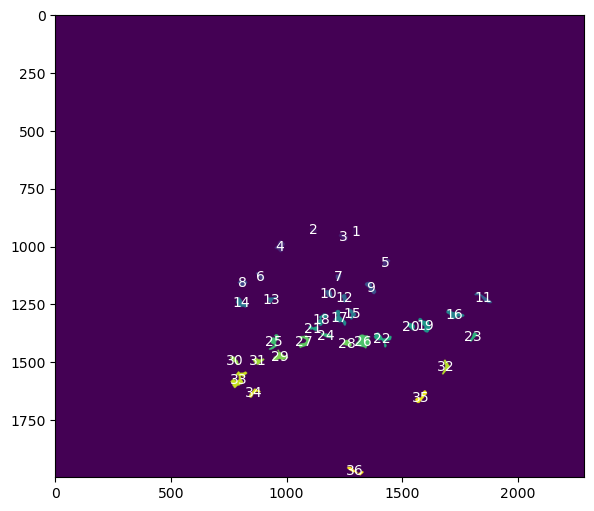

In [26]:
def get_plume_mask(img, pct=97, open_iters=4, close_iters=4, min_size=500):
    """
    img: 2D array (NaNs allowed)
    pct: percentile used for threshold (e.g., 95–99)
    open_iters/close_iters: morphology to denoise/bridge small gaps
    min_size: drop tiny specks before picking the two largest blobs
    """
    # 1) Threshold on high values (tune pct as needed)
    valid = np.isfinite(img)
    thr = np.nanpercentile(img, pct)
    bw = valid & (img >= thr)

    # 2) Morphology to clean the mask
    # Opening removes salt noise; closing bridges small gaps.
    bw = ndi.binary_opening(bw, iterations=open_iters)
    bw = ndi.binary_closing(bw, iterations=close_iters)

    # Remove very small objects
    lbl, n = ndi.label(bw)
    if n == 0:
        return np.zeros_like(bw, bool), np.zeros_like(bw, bool)

    sizes = ndi.sum(np.ones_like(bw), labels=lbl, index=np.arange(1, n+1))
    keep = {i+1 for i, s in enumerate(sizes) if s >= min_size}
    bw = np.isin(lbl, list(keep))

    # Re-label after size filter, fill holes
    lbl, n = ndi.label(bw)
    if n == 0:
        return np.zeros_like(bw, bool), np.zeros_like(bw, bool)
    lbl = ndi.binary_fill_holes(lbl>0).astype(int) * lbl

    return lbl

lbls = get_plume_mask(tv, pct=90, open_iters=4, close_iters=4)

plt.figure(figsize=(10,6))
plt.imshow(lbls, cmap='viridis')# extent=bounds)
# plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')

# unique labels, excluding background (0)
regions = np.unique(lbls)
regions = regions[regions != 0]

for r in regions:
    cy, cx = center_of_mass(lbls == r)
    plt.text(cx, cy, str(r), color='white', fontsize=10, ha='center', va='center')

plt.show()

11207


Text(0, 0.5, 'Latitude')

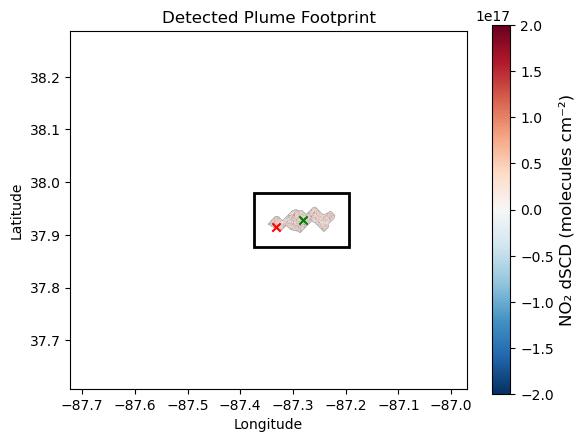

In [27]:
PLUME_ID = [28,26,22]

plume_mask = np.isin(lbls, PLUME_ID)


plume_mask_filled = binary_fill_holes(plume_mask)
plume_mask_filled = binary_dilation(plume_mask_filled, iterations=50)
plume_mask_filled = binary_fill_holes(plume_mask_filled)
plume_mask_filled = binary_erosion(plume_mask_filled, iterations=40)
plume_mask_filled = binary_fill_holes(plume_mask_filled)

# plume_mask_filled = np.load(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_retrieval_mask.npy")

plume_size_init = np.sum([1 if k else 0 for k in plume_mask_filled.flatten()])
print(plume_size_init)

## Get plume dSCD
dSCD_plume_masked = np.where(plume_mask_filled, dSCD_nan, np.nan)

## Get plume center
rows, cols = np.indices(dSCD_plume_masked.shape)
m = np.isfinite(dSCD_plume_masked)
xw = np.nansum(cols[m] * np.clip(dSCD_plume_masked[m], 0, None) ) / np.nansum(np.clip(dSCD_plume_masked[m], 0, None))
yw = np.nansum(rows[m] * np.clip(dSCD_plume_masked[m], 0, None) ) / np.nansum(np.clip(dSCD_plume_masked[m], 0, None))

## Boundary for full image, get a grid for lat/lon
bounds = (np.min(ds['longitude'].values), np.max(ds['longitude'].values),
          np.min(ds['latitude'].values),  np.max(ds['latitude'].values))

lon_grid = np.linspace(np.min(ds['longitude'].values), np.max(ds['longitude'].values), num=dSCD_plume_masked.shape[1])
lat_grid = np.linspace(np.min(ds['latitude'].values), np.max(ds['latitude'].values), num=dSCD_plume_masked.shape[0])

## Get bounding box
y_mask, x_mask = np.where(~np.isnan(dSCD_plume_masked))
pad = 50
bbox = (max(0, x_mask.min()-pad), min(len(lon_grid)-1, x_mask.max()+pad),
        max(-len(lat_grid)+1, -y_mask.min()+pad), min(0, -y_mask.max()-pad))

bounding_box = (lon_grid[bbox[0]], lon_grid[bbox[1]], 
                lat_grid[bbox[2]], lat_grid[bbox[3]])


im = plt.imshow(dSCD_plume_masked, cmap='RdBu_r', extent=bounds, vmin=-2e17, vmax=2e17)
cb = plt.colorbar(im)
cb.set_label("NO₂ dSCD (molecules cm⁻²)", fontsize=12)
plt.scatter([lon_grid[int(xw)]], [lat_grid[-int(yw)]], marker='x', c='g')
plt.scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red')

lon_min, lon_max, lat_min, lat_max = bounding_box
rect = patches.Rectangle((lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
                 linewidth=2, edgecolor='k', facecolor='none')
plt.gca().add_patch(rect)

plt.xlim(lonmin_bnd, lonmax_bnd)
plt.ylim(latmin_bnd, latmax_bnd)

plt.title("Detected Plume Footprint")
plt.xlabel('Longitude')
plt.ylabel('Latitude')

11807


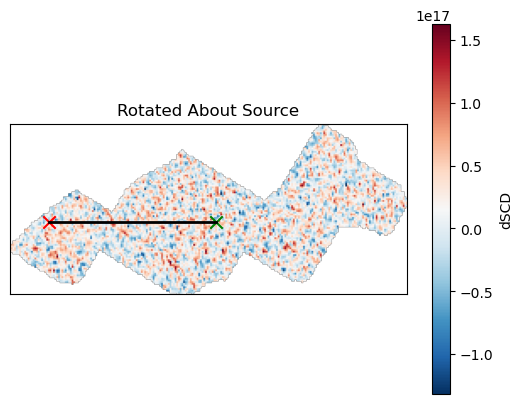

In [28]:
# --- helpers ---
ni = lambda v,a: int(np.argmin(np.abs(a - v)))

# pixel indices (global)
Rr,Rc = len(lat_grid)-ni(loc_data['LAT'], lat_grid), ni(loc_data['LON'], lon_grid) 
Gr, Gc = int(yw), int(xw)

# tight crop (with pad)
ym,xm = np.where(np.isfinite(dSCD_plume_masked)); pad=50
r0,r1 = max(0, ym.min()-pad), min(dSCD_plume_masked.shape[0], ym.max()+pad+1)
c0,c1 = max(0, xm.min()-pad), min(dSCD_plume_masked.shape[1], xm.max()+pad+1)
img   = dSCD_plume_masked[r0:r1, c0:c1].copy()
Rr,Rc,Gr,Gc = Rr-r0, Rc-c0, Gr-r0, Gc-c0

# plt.imshow(img); plt.scatter([Rc], [Rr]); plt.scatter([Gc], [Gr]); plt.show()

# angle to make red→green horizontal to the RIGHT
dx, dy = (Gc-Rc), (Gr-Rr)
angle  = -np.degrees(np.arctan2(-dy, dx))   # rotate by this

# pad so nothing clips; shift so RED at center
H,W = img.shape; P = max(H,W)
img  = np.pad(img, P, constant_values=np.nan)
Rr,Rc,Gr,Gc = Rr+P, Rc+P, Gr+P, Gc+P
H,W = img.shape; cy, cx = H/2, W/2

valid = np.isfinite(img).astype(float)

# plt.imshow(valid); plt.scatter([Rc], [Rr]); plt.scatter([Gc], [Gr]); plt.show()

vals  = np.nan_to_num(img, nan=0.0)
shift_vec = (cy - Rr, cx - Rc)
vals  = shift(vals,  shift_vec, order=1, mode='constant', cval=0.0, prefilter=False)
valid = shift(valid, shift_vec, order=1, mode='constant', cval=0.0, prefilter=False)

# plt.imshow(valid)
# print(vals.shape)
# print(valid.shape)

# normalized rotation (preserve plume; expand canvas)
num = rotate(vals*valid, angle, reshape=True, order=1, mode='constant', cval=0.0, prefilter=False)
den = rotate(valid,      angle, reshape=True, order=1, mode='constant', cval=0.0, prefilter=False)
with np.errstate(divide='ignore', invalid='ignore'):
    img_rot = num/den
img_rot[den < 1e-6] = np.nan

# plt.imshow(img_rot);
# print(np.isnan(img_rot))
plume_size_rot = np.sum([0 if k else 1 for k in np.isnan(img_rot.flatten())])
print(plume_size_rot)

# rotate GREEN relative to RED using the CORRECT image-space mapping
theta = np.deg2rad(-angle); c,s = np.cos(theta), np.sin(theta)
x_r =  c*dx - s*dy
y_r =  s*dx + c*dy

# red is now at canvas center; green goes to the right at same y
Rx, Ry = img_rot.shape[1]/2, img_rot.shape[0]/2
Gx, Gy = Rx + x_r, Ry + y_r   # Gy == Ry (horizontal), x_r > 0 (to the right)

# plot in pixel space (no lon/lat ticks)
plt.figure()
vmin, vmax = np.nanpercentile(img, [1,99]) if np.isfinite(img).any() else (None,None)
plt.imshow(img_rot, origin='upper', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(label='dSCD')
plt.plot([Rx, Gx], [Ry, Gy], 'k-', lw=2)        # horizontal by construction
plt.scatter([Rx],[Ry], c='r', marker='x', s=80) # source (center)
plt.scatter([Gx],[Gy], c='g', marker='x', s=80) # plume center (to the right)
ax=plt.gca()
# ax.set_xticks([]); ax.set_yticks([]); 
ax.set_aspect('equal','box')
plt.title('Rotated About Source')


vy = np.where(~np.isnan(img_rot))[0]
vx = np.where(~np.isnan(img_rot))[1]

plt.xlim(vx.min(), vx.max())
plt.ylim(vy.min(), vy.max())

plt.xticks([])
plt.yticks([])

plt.show()

In [29]:
AVOG = 6.02214076e23
img_rot_vcd = (img_rot / amf_eff) * (1e4 / AVOG)

# plot in pixel space (no lon/lat ticks)
plt.figure()
vmin, vmax = np.nanpercentile(img_rot_vcd, [1,99]) if np.isfinite(img_rot_vcd).any() else (None,None)
lim = max(abs(vmin), abs(vmax))

im=plt.imshow(img_rot_vcd, origin='upper', cmap='RdBu_r', vmin=-abs(lim), vmax=abs(lim))
cb = fig.colorbar(im, ax=plt.gca(), shrink=0.85, pad=0.05)
# cb.set_label("NO₂ DSCD (molecules cm⁻²)", fontsize=12)
cb.set_label("NO₂ vertical column density (mol m$^{-2}$)", fontsize=10)
cb.formatter.set_powerlimits((0,0))   # force scientific notation
cb.update_ticks()
cb.ax.tick_params(labelsize=10)   # change 16 → whatever size you want
cb.ax.yaxis.get_offset_text().set_size(8)


plt.plot([Rx, Gx], [Ry, Gy], 'k-', lw=2)        # horizontal by construction
plt.scatter([Rx],[Ry], c='r', marker='x', s=80) # source (center)
plt.scatter([Gx],[Gy], c='g', marker='x', s=80) # plume center (to the right)
ax=plt.gca()

ax.set_aspect('equal','box')
plt.title('Rotated About Source')

vy = np.where(~np.isnan(img_rot))[0]
vx = np.where(~np.isnan(img_rot))[1]

plt.xlim(vx.min(), vx.max())
plt.ylim(vy.min(), vy.max())

np.save(f"PLOT_DATA/{loc_name}_{granule_name}_rotated_vcd.npy", img_rot_vcd)
np.save(f"PLOT_DATA/{loc_name}_{granule_name}_locs.npy", np.array([[Rx,Ry], [Gx,Gy]]))

plt.xticks([])
plt.yticks([])

plt.show()

NameError: name 'amf_eff' is not defined

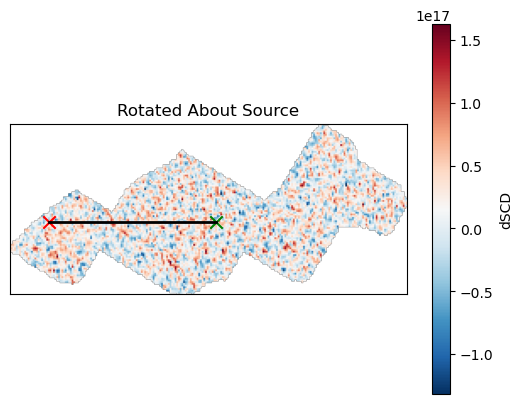

In [30]:
# 1) Compute per-column mean using ONLY pixels inside outer boundary
A = img_rot.copy()   # (H, W), NaNs outside + holes inside

H, W = A.shape
A_filled = A.copy()

for j in range(W):
    col = A[:, j]

    valid = np.isfinite(col)
    if not np.any(valid):
        continue  # whole column is outside swath

    i0 = np.argmax(valid)                 # first valid row
    i1 = H - 1 - np.argmax(valid[::-1])   # last valid row

    col_mean = np.nanmean(col[i0:i1+1])

    # fill NaNs ONLY inside outer boundary
    fill_idx = np.isnan(col) & (np.arange(H) >= i0) & (np.arange(H) <= i1)
    A_filled[fill_idx, j] = col_mean

# plot in pixel space (no lon/lat ticks)
plt.figure()
vmin, vmax = np.nanpercentile(img, [1,99]) if np.isfinite(img).any() else (None,None)
plt.imshow(A_filled, origin='upper', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(label='dSCD')
plt.plot([Rx, Gx], [Ry, Gy], 'k-', lw=2)        # horizontal by construction
plt.scatter([Rx],[Ry], c='r', marker='x', s=80) # source (center)
plt.scatter([Gx],[Gy], c='g', marker='x', s=80) # plume center (to the right)
ax=plt.gca()
# ax.set_xticks([]); ax.set_yticks([]); 
ax.set_aspect('equal','box')
plt.title('Rotated About Source')


vy = np.where(~np.isnan(img_rot))[0]
vx = np.where(~np.isnan(img_rot))[1]

plt.xlim(vx.min(), vx.max())
plt.ylim(vy.min(), vy.max())

plt.xticks([])
plt.yticks([])

plt.show()


img_rot = A_filled

In [31]:
l2a_fpath  = f"{CONFIG['data_folder']}/{loc_name}/EMIT_L2A_RFL_001_{granule_name}.nc"
L2A_xarr = emit_xarray(l2a_fpath, ortho=True)

emit_spec_wlen = L2A_xarr["wavelengths"].to_numpy().astype(np.float64)
window_sel = (emit_spec_wlen >= 405) & (emit_spec_wlen <= 465)
gler = L2A_xarr['reflectance'].sel(wavelengths=window_sel, method='nearest').values
gler = np.where(gler > -8000, gler, np.nan)
gler = np.nanmean(gler, axis=-1)
gler = np.nanmean(np.where(plume_mask_filled, gler, np.nan))

del L2A_xarr

obs_fpath  = f"{CONFIG['data_folder']}/{loc_name}/EMIT_L1B_OBS_001_{granule_name}.nc"
OBS_xarr = emit_xarray(obs_fpath, ortho=True)
obs_src = np.where(OBS_xarr['obs'] > -8000, OBS_xarr['obs'], np.nan)

sza = np.nanmean(np.where(plume_mask_filled, obs_src[:,:,4], np.nan))
vza = np.nanmean(np.where(plume_mask_filled, obs_src[:,:,2], np.nan))

to_sensor_az = np.array(obs_src[:,:,1])
to_sun_az = np.array(obs_src[:,:,3])
rel_azimuth = np.abs(to_sensor_az-to_sun_az)
rel_azimuth = np.minimum(rel_azimuth, 360.0 - rel_azimuth) # wrap to 0-180
phi = np.nanmean(np.where(plume_mask_filled, rel_azimuth, np.nan))

del OBS_xarr

# Convert altitude to pressure via barometric formula with H=8km
H = 287.05 * geosfp_info['T2M'] / 9.81  # scale height in meters
surface_pressure = np.clip(geosfp_info['PS'], 112, 1012) # clip to range of LUT
pressure_at_500m = np.clip(surface_pressure * np.exp(-500/H), 1, 1019)
# print(f"Pressure at 500m above ground = {pressure_at_500m} hPa")

print(f"{gler=} {sza=} {vza=} {phi=}, {surface_pressure=}, {pressure_at_500m=}")

AMF_LUT = xr.load_dataset(CONFIG['AMF_LUT'])
amf_profile = AMF_LUT["damf"].interp(dspres=surface_pressure, 
                                     dpres=pressure_at_500m,
                                     dalb=gler, dphi=phi, 
                                     dvza=vza, dsza=sza).data

amf_eff = amf_profile+0 # for some reason this typecasts it properly

del AMF_LUT

amf_eff

gler=0.032922104 sza=42.687878 vza=7.739372 phi=142.46722, surface_pressure=993.3565625, pressure_at_500m=937.9961532224505


0.7766405251462298

Approx pixel pitch: 61.78 m/pix
Plume-integrated NO₂ mass (kg·m⁻¹): 1.296e+01
Mean retrieved emission rate: 0.23 kg/s
Mean CAMPD emission rate: 0.11 kg/s


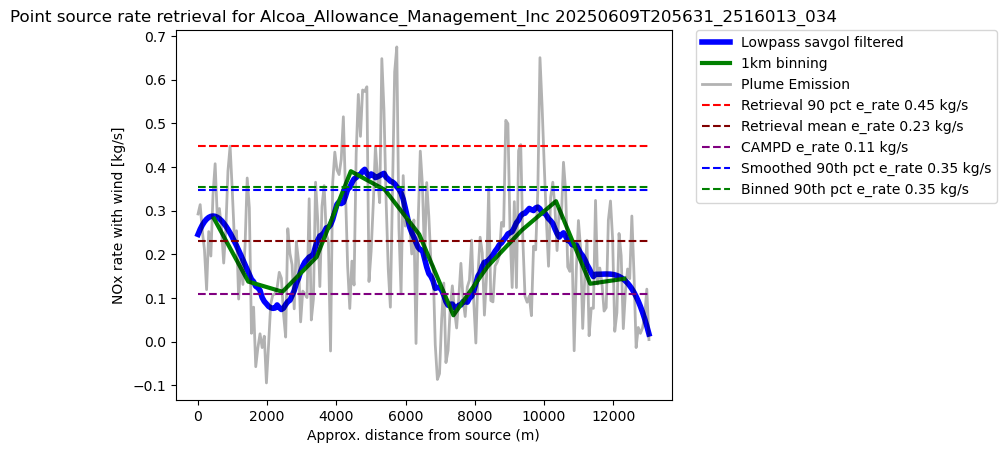

In [33]:
pix_pitch = pix_pitch_m * np.sqrt(plume_size_rot/plume_size_init)
print(f"Approx pixel pitch: {pix_pitch:0.4} m/pix")

AMF = amf_eff
integrated_flux = np.nansum(img_rot, axis=0)*pix_pitch/AMF

# integrated_flux already defined
molec_to_kg_NO2 = 46 / (6.022e23 * 1000)
NOx_NO2_ratio = 1.4 # common value
NO2_kg_m2 = integrated_flux * molec_to_kg_NO2 * NOx_NO2_ratio * 1e4 # cm² → m²

# define indices
start_idx = int(Rx)  # source (red cross)
end_idx = np.where(NO2_kg_m2 > 0)[0][-1]

# threshold = 0.05 * np.nanmax(NO2_kg_m2)  # e.g. 5% of peak as cutoff
# end_idx = start_idx + np.argmax(NO2_kg_m2[start_idx:] < threshold)

# restrict the array
x = np.arange(len(NO2_kg_m2))
NO2_restricted = NO2_kg_m2[start_idx:end_idx]

# compute total plume mass (integrated along track)
plume_mass = np.nansum(NO2_restricted)
print(f"Plume-integrated NO₂ mass (kg·m⁻¹): {plume_mass:.3e}")

plume_extent = x[start_idx:end_idx]*pix_pitch-start_idx*pix_pitch
plume_emission = NO2_kg_m2[start_idx:end_idx]

Q = plume_emission*mean_windspeed
e_rate = np.mean(Q[Q > 0])

print(f"Mean retrieved emission rate: {e_rate:0.2f} kg/s")
print(f"Mean CAMPD emission rate: {campd_e_rate:0.2f} kg/s")



smoothed = savgol_filter(Q, window_length=51, polyorder=3) #smooth over 60*51 ~= 3km

# Smooth then base on top 10% of emission data
smoothed_maxrate = np.mean(smoothed[smoothed >= np.percentile(smoothed, 80)])

binned = np.array([np.mean(Q[x:x+16]) for x in range(0,len(Q)-16,16)])
bin_extent = [np.mean(plume_extent[x:x+16]) for x in range(0,len(Q)-16,16)]
bin_maxrate = np.mean(binned[binned >= np.percentile(binned, 80)])
plt.plot(bin_extent, binned)

nofilt_maxrate = np.mean(Q[Q >= np.percentile(Q, 80)])


plt.plot(plume_extent, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
plt.plot(bin_extent, binned, 'green', lw=3, label='1km binning')
plt.plot(plume_extent, Q, 'k', lw=2, label='Plume Emission', alpha=0.3)

plt.hlines([nofilt_maxrate], xmin=0, xmax=np.max(plume_extent), color='red', linestyle='--', 
           label=f'Retrieval 90 pct e_rate {nofilt_maxrate:0.2f} kg/s')
plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent), color='maroon', linestyle='--', 
           label=f'Retrieval mean e_rate {e_rate:0.2f} kg/s')
plt.hlines([campd_e_rate], xmin=0, xmax=np.max(plume_extent), color='purple', linestyle='--', 
           label=f'CAMPD e_rate {campd_e_rate:0.2f} kg/s')
plt.hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent), color='blue', linestyle='--', 
           label=f'Smoothed 90th pct e_rate {smoothed_maxrate:0.2f} kg/s')
plt.hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent), color='green', linestyle='--', 
           label=f'Binned 90th pct e_rate {bin_maxrate:0.2f} kg/s')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
# plt.legend()
plt.title(f"Point source rate retrieval for {loc_name} {granule_name}")
plt.xlabel('Approx. distance from source (m)')
plt.ylabel('NOx rate with wind [kg/s]');

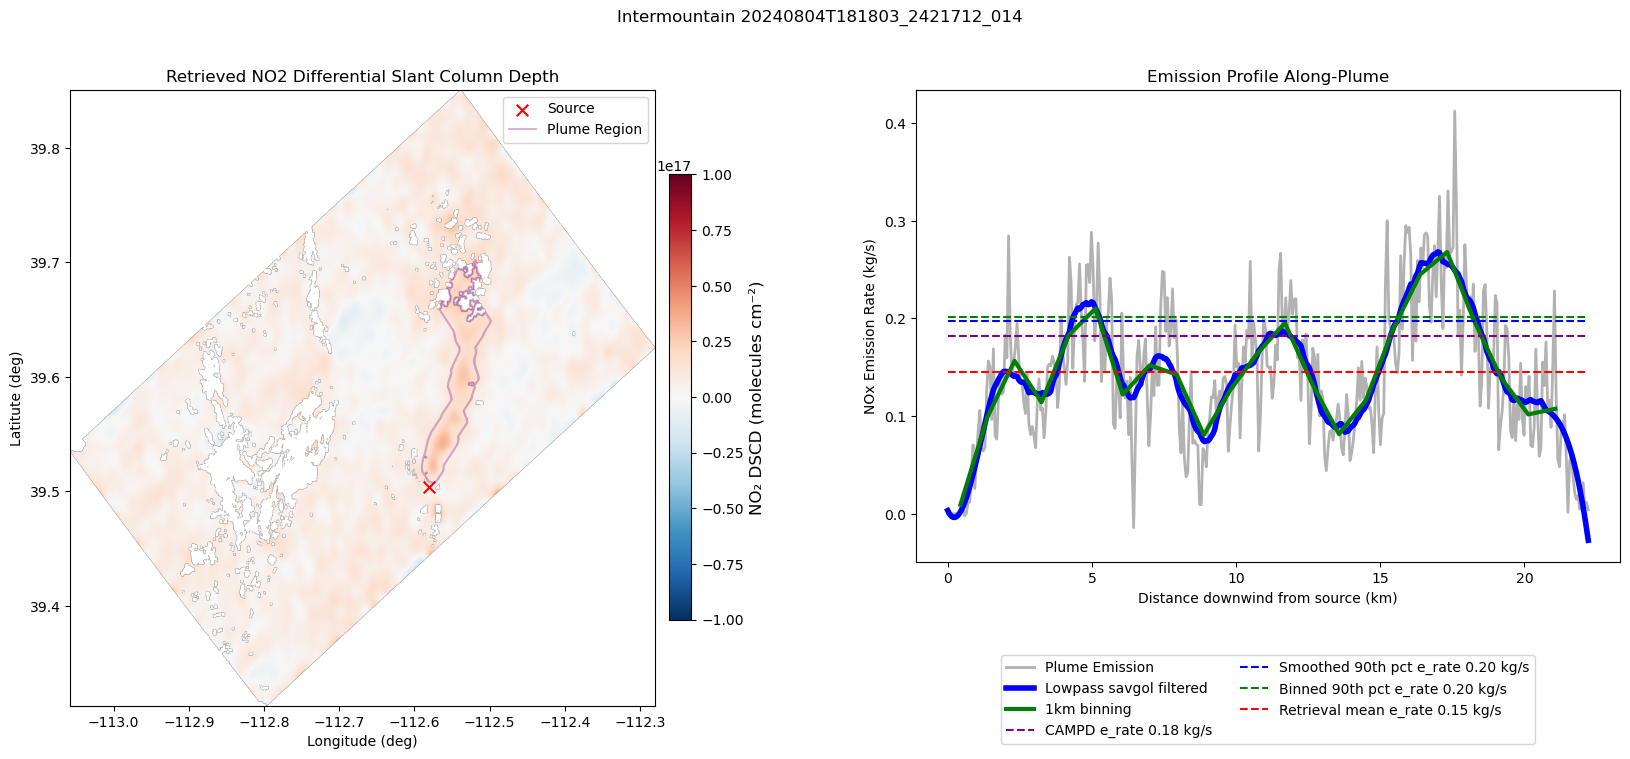

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,8))

# plot_img = tv*1e19
plot_img = dSCD_nan

SIGMA=2
Z_gauss = tv*1e19#ndi.gaussian_filter(dSCD_nan, sigma=SIGMA)   # try sigma=0.8–1.5
im = ax[0].imshow(Z_gauss, cmap='RdBu_r', origin='upper', 
              aspect='auto', vmin=-1e17, vmax=1e17, extent=bounds)
# cb = fig.colorbar(im, ax=ax[0])

cb = fig.colorbar(im, ax=ax[0], shrink=0.85, pad=0.02)
cb.set_label("NO₂ DSCD (molecules cm⁻²)", fontsize=12)
# shrink height and move it down slightly
cb.ax.set_position([
    cb.ax.get_position().x0,          # same left
    cb.ax.get_position().y0 + 0.05,   # move down a bit
    cb.ax.get_position().width,       # same width
    cb.ax.get_position().height * 0.85  # shrink height (0.85 = 85%)
])
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red', s=70, label='Source')
ax[0].contour(~np.isnan(dSCD_plume_masked[:,:]), levels=[0.5], 
            colors='purple', alpha=0.3, linestyle='-', linewidths=1.5,
            extent=[bounds[0], bounds[1], bounds[3], bounds[2]])
ax[0].plot([], color='purple', alpha=0.3, label='Plume Region')
ax[0].legend()
ax[0].set_title("Retrieved NO2 Differential Slant Column Depth")
ax[0].set_xlabel("Longitude (deg)")
ax[0].set_ylabel("Latitute (deg)")

ax[0].set_xlim(lonmin_bnd, lonmax_bnd)
ax[0].set_ylim(latmin_bnd, latmax_bnd)

ax[1].plot(np.array(plume_extent)/1000, Q, 'k', lw=2, label='Plume Emission', alpha=0.3)
ax[1].plot(np.array(plume_extent)/1000, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
ax[1].plot(np.array(bin_extent)/1000, binned, 'green', lw=3, label='1km binning')

ax[1].hlines([campd_e_rate], xmin=0, xmax=np.max(plume_extent)/1000, color='purple', linestyle='--', 
           label=f'CAMPD e_rate {campd_e_rate:0.2f} kg/s')
ax[1].hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='blue', linestyle='--', 
           label=f'Smoothed 90th pct e_rate {smoothed_maxrate:0.2f} kg/s')
ax[1].hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='green', linestyle='--', 
           label=f'Binned 90th pct e_rate {bin_maxrate:0.2f} kg/s')
plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent)/1000, color='red', linestyle='--', 
           label=f'Retrieval mean e_rate {e_rate:0.2f} kg/s')
# ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# shrink just this subplot height to make room
pos = ax[1].get_position()
ax[1].set_position([pos.x0, pos.y0 + 0.18, pos.width, pos.height - 0.18])

# legend under plot
ax[1].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.40),
    ncol=2
)

ax[1].set_ylabel("NOx Emission Rate (kg/s)")
ax[1].set_xlabel("Distance downwind from source (km)")
ax[1].set_title("Emission Profile Along-Plume")

os.makedirs(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}", exist_ok=True)
os.makedirs(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}", exist_ok=True)

plt.suptitle(f"{loc_name} {granule_name}")
plt.savefig(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{granule_name}_PLOT.png")

In [35]:
retrieval_log_fn = f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/source_retr_data.csv"
datalog_cols = ['LOC_NAME', 'GRANULE', 'CAMPD', 'SMOOTHED', 'BINNED', 'MEAN', 'AMF']

g_dat = {'LOC_NAME': loc_name,
        'GRANULE': granule_name,
        'CAMPD': campd_e_rate,
        'SMOOTHED': smoothed_maxrate,
        'BINNED': bin_maxrate,
        'MEAN': e_rate,
        'AMF': amf_eff}

if os.path.exists(retrieval_log_fn):
    retr_log = pd.read_csv(retrieval_log_fn) 
else:
    retr_log = pd.DataFrame(columns=datalog_cols)

if granule_name not in retr_log['GRANULE'].values:
    retr_log = pd.concat([retr_log, pd.DataFrame(g_dat, index=[0])])
else:
    retr_log.loc[retr_log['GRANULE'] == granule_name, datalog_cols[2:]] = [
        campd_e_rate, smoothed_maxrate, bin_maxrate, e_rate, amf_eff
    ]
retr_log.to_csv(retrieval_log_fn, index=False)

AVOG = 6.02214076e23
retr_vcd = (dSCD_nan / amf_eff) * (1e4 / AVOG)   # molecules/cm^2 -> mol/m^2

mask = np.isfinite(dSCD_plume_masked)  # or: mask = plume_mask_bool
mask = ndi.binary_fill_holes(mask)

# remove tiny speckles so you don’t get random little loops
mask = ndi.binary_opening(mask, structure=np.ones((3,3)))
mask = mask.astype(bool)

loc_bounds = np.array([lonmin_bnd, lonmax_bnd, latmin_bnd, latmax_bnd])

# Save all sorts of data products
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_plume_ext", plume_extent)
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_profile", Q)
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_smoothed", smoothed)
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_rates", np.array([campd_e_rate, smoothed_maxrate]))
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_retrieval_field.npy", retr_vcd)
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_retrieval_bounds.npy", loc_bounds)
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_retrieval_plot_bounds.npy", bounds)
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_retrieval_mask.npy", mask)
np.save(f"{CONFIG['results_folder']}/{CONFIG['ps_subdir']}/{loc_name}/{loc_name}_{granule_name}_retrieval_loc.npy", loc_data)

FileNotFoundError: [Errno 2] No such file or directory: 'Colstrip/retr_Colstrip.csv'

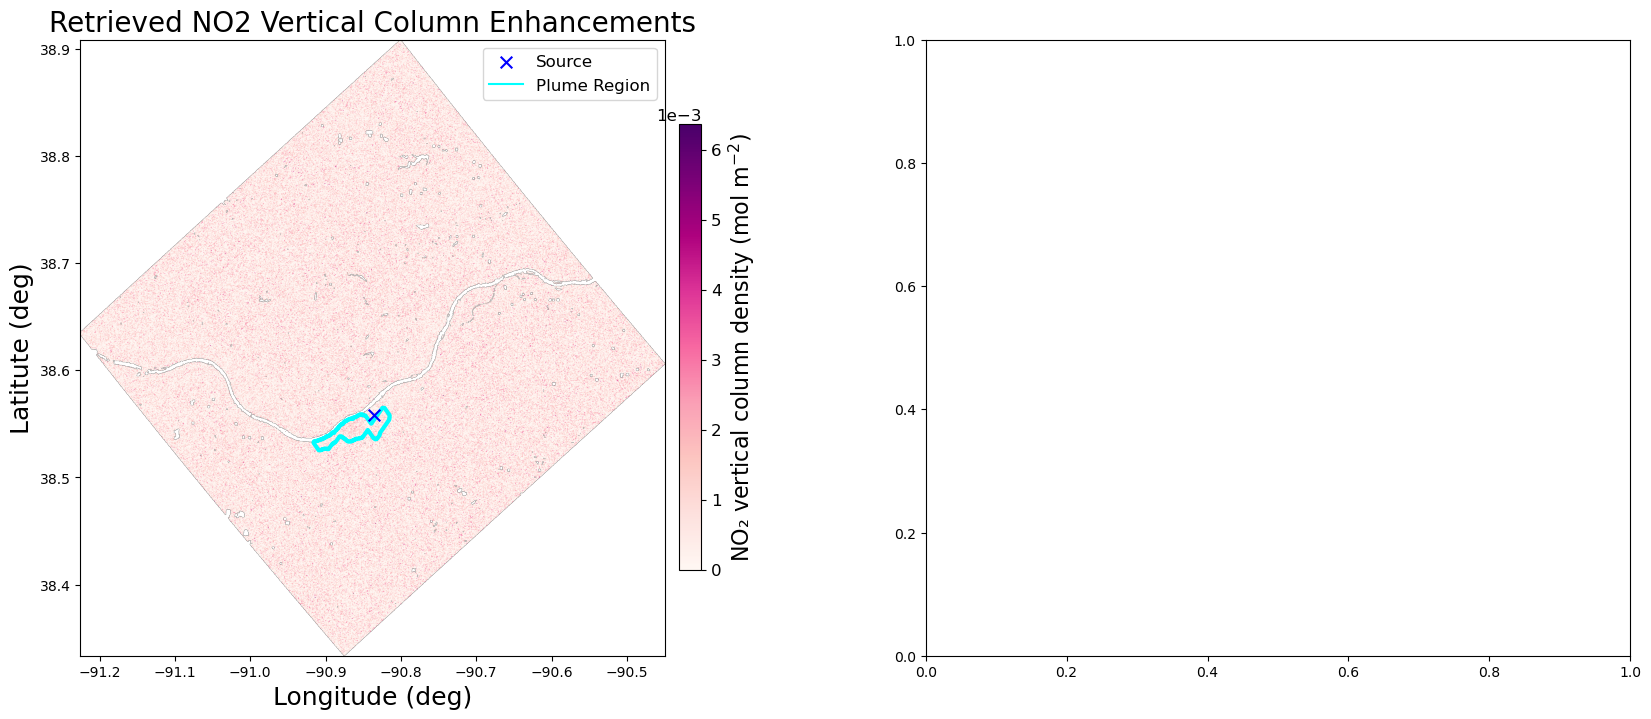

In [30]:
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression
import matplotlib.lines as mlines
import numpy as np
import scipy.ndimage as ndi
from matplotlib.colors import PowerNorm

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20,8))

# plot_img = tv*1e19
# plot_img = dSCD_nan

AVOG = 6.02214076e23
retr_vcd = (plot_img / amf_eff) * (1e4 / AVOG)   # molecules/cm^2 -> mol/m^2


# ---------- 1) DENOISE (kills salt-and-pepper without inventing structure) ----------
# median removes speckle; gaussian makes it look like a field again
Zf = retr_vcd.copy()
valid = np.isfinite(Zf)
Zf[~valid] = np.nanmedian(Zf[valid])

Z_med = ndi.median_filter(Zf, size=5)           # try size=3 or 5
Z_s   = ndi.gaussian_filter(Z_med, sigma=3)   # try sigma=0.8–1.5
Z_s = Zf
# put NaNs back for plotting
Z_s[~valid] = np.nan

cmap = 'RdPu'
# ---------- 2) PLOT with ROBUST LIMITS (don’t stretch to noise outliers) ----------
# vmin, vmax = np.nanpercentile(Z_s, [5, 95])     # try [2,98] or [10,90]
im = axs[0].imshow(
    Z_s, cmap=cmap,
    extent=bounds, aspect="auto",
    vmin=0, vmax=1.05*np.nanmax(Z_s)#np.nanpercentile(Z_s, 99.5)
)



# ----------------------------
# 2) Outer contour ONLY (fill holes + drop tiny islands)
# ----------------------------
mask = np.isfinite(dSCD_plume_masked)  # or: mask = plume_mask_bool
mask = ndi.binary_fill_holes(mask)

# remove tiny speckles so you don’t get random little loops
mask = ndi.binary_opening(mask, structure=np.ones((3,3)))
mask = mask.astype(bool)

# keep only the largest connected component (outer plume blob)
lab, nlab = ndi.label(mask)
if nlab > 0:
    sizes = ndi.sum(mask, lab, index=np.arange(1, nlab+1))
    keep = 1 + np.argmax(sizes)
    mask = (lab == keep)

# Now a single outer boundary
axs[0].contour(
    mask.astype(float),
    levels=[0.5],
    colors="cyan",
    linewidths=3,
    extent=[bounds[0], bounds[1], bounds[3], bounds[2]],
)

# source marker etc
axs[0].scatter([loc_data["LON"]], [loc_data["LAT"]], marker="x", c="blue", s=70, label="Source",zorder=10)

loc_bounds = np.array([lonmin_bnd, lonmax_bnd, latmin_bnd, latmax_bnd])


# im = axs[0].imshow(
#     retr_vcd, cmap='cividis',
#     # origin="lower",  # because extent is in increasing y
#     extent=bounds, aspect="auto", vmin=0.0002, vmax=0.0015
# )
# im = axs[0].imshow(retr_vcd, cmap='cividis', origin='upper', 
#               aspect='auto', vmin=0, vmax=8e16, extent=bounds)
# vmin=-2e17, vmax=2e17
# im = axs[0].imshow(plot_img, cmap='seismic', origin='upper', 
#               aspect='auto', vmin=0, vmax=1e18, extent=bounds)

cb = fig.colorbar(im, ax=axs[0], shrink=0.85, pad=0.02)
# cb.set_label("NO₂ DSCD (molecules cm⁻²)", fontsize=12)
cb.set_label("NO₂ vertical column density (mol m$^{-2}$)", fontsize=16)
cb.formatter.set_powerlimits((0,0))   # force scientific notation
cb.update_ticks()
cb.ax.tick_params(labelsize=12)   # change 16 → whatever size you want
cb.ax.yaxis.get_offset_text().set_size(12)

# shrink height and move it down slightly
cb.ax.set_position([
    cb.ax.get_position().x0,          # same left
    cb.ax.get_position().y0 + 0.05,   # move down a bit
    cb.ax.get_position().width,       # same width
    cb.ax.get_position().height * 0.85  # shrink height (0.85 = 85%)
])
# axs[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red', s=70, label='Source')
# axs[0].contour(~np.isnan(dSCD_plume_masked[:,:]), levels=[0.5], 
#             colors='red', alpha=1, linestyle='-', linewidths=3,
#             extent=[bounds[0], bounds[1], bounds[3], bounds[2]])
axs[0].plot([], color='cyan', alpha=1, label='Plume Region',zorder=-1)
axs[0].legend(fontsize=12)
axs[0].set_title("Retrieved NO2 Vertical Column Enhancements", fontsize=20)
axs[0].set_xlabel("Longitude (deg)",fontsize=18)
axs[0].set_ylabel("Latitute (deg)",fontsize=18)

axs[0].set_xlim(lonmin_bnd, lonmax_bnd)
axs[0].set_ylim(latmin_bnd, latmax_bnd)


csv_savefn = f"{CONFIG['data_folder']}/metadata.csv"
data = pd.read_csv(csv_savefn)

dfs_merge = []

colormap_loc = {
    'Colstrip': '#1F77B4',                  # strong blue
    'Fort_Martin_Power_Station': '#FF7F0E', # vivid orange
    'Gerald_Gentleman_Station': '#2CA02C',  # strong green
    'Intermountain': '#D62728',             # strong red
    'Ghent': '#9467BD',                     # purple
    'Laramie_River': '#17BECF',             # cyan (distinct from blue)
    # 'Martin_Lake': '#7F7F7F',               # neutral gray
    'Mill_Creek': '#8C564B',                # brown
    'New_Madrid_Power_Plant': '#BCBD22',    # yellow-green/olive (bright)
    'Ninemile_Point': '#000000',            # black (max contrast)
    'Shawnee': '#E377C2',                   # pink/magenta
    'W_A_Parish': '#FFD700',                # gold (very bright, highly distinct)
}

for ln in colormap_loc.keys():
    dfl = data[data['LOC_NAME'] == ln]
    rlogfn = f'{ln}/retr_{ln}.csv'
    retr_log = pd.read_csv(rlogfn)

    dfs_merge.append(dfl.merge(
        retr_log,
        on="GRANULE",
        how="inner",
        validate="one_to_one"  # change to "many_to_one" if retr_log has unique GRANULE but df_loc doesn't
    ))

plot_df = pd.concat(dfs_merge, axis=0, ignore_index=True)
plot_df = plot_df[plot_df['AMF'] < 2.8]

granules_to_drop = [
    '20240330T183916_2409012_029', # failed
    '20240621T160640_2417311_031', # unquantifiable
    '20231006T161159_2327911_004', # unquantifiable
    '20250602T165109_2515311_026', # unquantifiable - wind looks like it turned around
    '20240815T191038_2422813_023', # unquantifiable
]

plot_df = plot_df[~plot_df['GRANULE'].isin(granules_to_drop)]

x = plot_df["CAMPD_RATE"].to_numpy(dtype=float) #* plot_df["AMF"].to_numpy(dtype=float)/1.4
y = 1.*plot_df["SMOOTHED"].to_numpy(dtype=float)+\
    0.*plot_df['MEAN'].to_numpy(dtype=float)

spd_cols = ['HRRR_AGL_SPD', 'HRRR_10M_SPD', 'GEOSFP_50M_SPD']
U_mean = plot_df[spd_cols].mean(axis=1).to_numpy(float)
U_cv = (plot_df[spd_cols].std(axis=1) /
        plot_df[spd_cols].mean(axis=1)).to_numpy(float)

err = y - x

# linear least-squares fit: err = a * U_mean + b
m, b = np.polyfit(U_mean, err, 1)

# fit line for plotting
u_fit = np.linspace(U_mean.min(), U_mean.max(), 200)
err_fit = m * u_fit + b

# inputs
# spd_cols = ['HRRR_AGL_SPD', 'HRRR_10M_SPD', 'GEOSFP_50M_SPD']
# U_mean = plot_df[spd_cols].mean(axis=1).to_numpy(float)
# wind_corr = 0.035*U_mean-0.1
# y -= wind_corr

c = np.array([colormap_loc[k] for k in plot_df["LOC_NAME"]])
# reshape for sklearn
X = x.reshape(-1, 1)

# RANSAC with linear model
ransac = RANSACRegressor(
    estimator=LinearRegression(fit_intercept=False),
    min_samples=max(3, int(0.6 * len(x))),  # robust default
    residual_threshold=3*np.nanstd(y-x),                # auto (MAD-based)
    random_state=42
)

ransac.fit(X,y)

# extract results
inlier_mask  = ransac.inlier_mask_
outlier_mask = ~inlier_mask

slope = ransac.estimator_.coef_[0]
intercept = ransac.estimator_.intercept_

print(f"RANSAC fit: y = {slope:.3f} x + {intercept:.3f}")
print(f"Inliers: {inlier_mask.sum()} / {len(x)}")

# fitted line for plotting
x_fit = np.linspace(0, 1.1*np.nanmax(x), 200)
y_fit = slope * x_fit + intercept

ax=axs[1]

ax.scatter(x[inlier_mask], y[inlier_mask], s=40, c=c[inlier_mask])
ax.scatter(x[outlier_mask], y[outlier_mask], s=40, c=c[outlier_mask], marker='x')

# --- Legend 1: plants (color only) ---
plant_handles = [
    mlines.Line2D([], [], linestyle='None', marker='o', markersize=8,
                  markerfacecolor=colormap_loc[name], markeredgecolor='none',
                  label=name.replace('_',' '))
    for name in colormap_loc.keys()
]

leg1 = ax.legend(
    handles=plant_handles,
    frameon=False,
    fontsize=12,
    loc="center left",
    bbox_to_anchor=(1.02, 0.60),
    title="Plant",
    title_fontsize=16,
    handletextpad=0.4
)
ax.add_artist(leg1)  # keep this legend when adding the second


resid = y - x
bias = np.nanmean(resid)
rmse = np.sqrt(np.nanmean(resid**2))
nrmse = rmse / np.nanmean(x)
mae = np.nanmean(np.abs(resid))

# --- Legend 2: inlier/outlier (shape only) ---
status_handles = [
    # mlines.Line2D([], [], linestyle='None', marker='o', markersize=8,
    #               markerfacecolor='none', markeredgecolor='k', markeredgewidth=1.5,
    #               label='RANSAC inliers'),
    # mlines.Line2D([], [], linestyle='None', marker='x', markersize=9,
    #               color='k', markeredgewidth=2,
    #               label='RANSAC outliers'),
    mlines.Line2D([], [], color='blue', markeredgewidth=2,
                  label=f"RANSAC fit line; y = {slope:0.3f}x\nBias (y−x): {bias:.2f}\nRMSE (vs 1:1): {rmse:.2f}\nNRMSE: {nrmse:.2%}\nMAE: {mae:.2f}")
]

ax.legend(
    handles=status_handles,
    frameon=False,
    fontsize=12,
    loc="center left",
    bbox_to_anchor=(1.02, 0.20),
    title="RANSAC",
    title_fontsize=16,
    handletextpad=0.6
)

plt.plot(x_fit, y_fit, color='blue', lw=2, label="RANSAC fit")
# 1:1 line
lims = [0, max(np.nanmax(x), np.nanmax(y)) * 1.1]
ax.plot(lims, lims, 'k--', lw=1)

ax.set_xlabel("Actual Emission Rate (EPA CAMPD, kg/s)",fontsize=18)
ax.set_ylabel("Retrieved Emission Rate (kg/s)",fontsize=18)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")


plt.tight_layout()
plt.title(f'Power Plant Source-Rate Retrievals',fontsize=20)


axs[0].tick_params(axis='both', labelsize=12) #
axs[1].tick_params(axis='both', labelsize=12) #

plt.show()



print(f"ALL:")
print(f"Bias (y−x): {bias:.2f}")
print(f"RMSE (vs 1:1): {rmse:.2f}")
print(f"NRMSE: {nrmse:.2%}")
print(f"MAE: {mae:.2f}")

resid = y[inlier_mask] - x[inlier_mask]
bias = np.nanmean(resid)
rmse = np.sqrt(np.nanmean(resid**2))
nrmse = rmse / np.nanmean(x[inlier_mask])
mae = np.nanmean(np.abs(resid))

print(f"\nRANSAC INLIERS:")
print(f"Bias (y−x): {bias:.2f}")
print(f"RMSE (vs 1:1): {rmse:.2f}")
print(f"NRMSE: {nrmse:.2%}")
print(f"MAE: {mae:.2f}")











# ax[1].plot(np.array(plume_extent)/1000, Q, 'k', lw=2, label='Plume Emission', alpha=0.3)
# ax[1].plot(np.array(plume_extent)/1000, smoothed,'blue', lw=4, label='Lowpass savgol filtered')
# ax[1].plot(np.array(bin_extent)/1000, binned, 'green', lw=3, label='1km binning')

# ax[1].hlines([campd_e_rate], xmin=0, xmax=np.max(plume_extent)/1000, color='purple', linestyle='--', 
#            label=f'CAMPD e_rate {campd_e_rate:0.2f} kg/s')
# ax[1].hlines([smoothed_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='blue', linestyle='--', 
#            label=f'Smoothed 90th pct e_rate {smoothed_maxrate:0.2f} kg/s')
# ax[1].hlines([bin_maxrate], xmin=0, xmax=np.max(plume_extent)/1000, color='green', linestyle='--', 
#            label=f'Binned 90th pct e_rate {bin_maxrate:0.2f} kg/s')
# plt.hlines([e_rate], xmin=0, xmax=np.max(plume_extent)/1000, color='red', linestyle='--', 
#            label=f'Retrieval mean e_rate {e_rate:0.2f} kg/s')
# # ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)


# # shrink just this subplot height to make room
# pos = ax[1].get_position()
# ax[1].set_position([pos.x0, pos.y0 + 0.18, pos.width, pos.height - 0.18])

# # legend under plot
# ax[1].legend(
#     loc="lower center",
#     bbox_to_anchor=(0.5, -0.40),
#     ncol=2
# )

# ax[1].set_ylabel("NOx Emission Rate (kg/s)")
# ax[1].set_xlabel("Distance downwind from source (km)")
# ax[1].set_title("Emission Profile Along-Plume")

# plt.suptitle(f"{loc_name} {granule_name}")
# plt.savefig(f"{loc_name}/{granule_name}_PLOT.png")

In [ ]:
dfs_merge = []

colormap_loc = {
    'Colstrip': '#1F77B4',                  # strong blue
    'Fort_Martin_Power_Station': '#FF7F0E', # vivid orange
    'Gerald_Gentleman_Station': '#2CA02C',  # strong green
    'Intermountain': '#D62728',             # strong red
    'Ghent': '#9467BD',                     # purple
    'Laramie_River': '#17BECF',             # cyan (distinct from blue)
    'Martin_Lake': '#7F7F7F',               # neutral gray
    'Mill_Creek': '#8C564B',                # brown
    'New_Madrid_Power_Plant': '#BCBD22',    # yellow-green/olive (bright)
    'Ninemile_Point': '#000000',            # black (max contrast)
    'Shawnee': '#E377C2',                   # pink/magenta
    'W_A_Parish': '#FFD700',                # gold (very bright, highly distinct)
}



for ln in colormap_loc.keys():
    dfl = data[data['LOC_NAME'] == ln]
    rlogfn = f'{ln}/retr_{ln}.csv'
    retr_log = pd.read_csv(rlogfn)

    dfs_merge.append(dfl.merge(
        retr_log,
        on="GRANULE",
        how="inner",
        validate="one_to_one"  # change to "many_to_one" if retr_log has unique GRANULE but df_loc doesn't
    ))

plot_df = pd.concat(dfs_merge, axis=0, ignore_index=True)
plot_df = plot_df[plot_df['AMF'] < 2.8]
# plot_df = plot_df[plot_df['AMF'] > 1]
plot_df

RANSAC fit: y = 0.893 x + 0.000
Inliers: 45 / 49


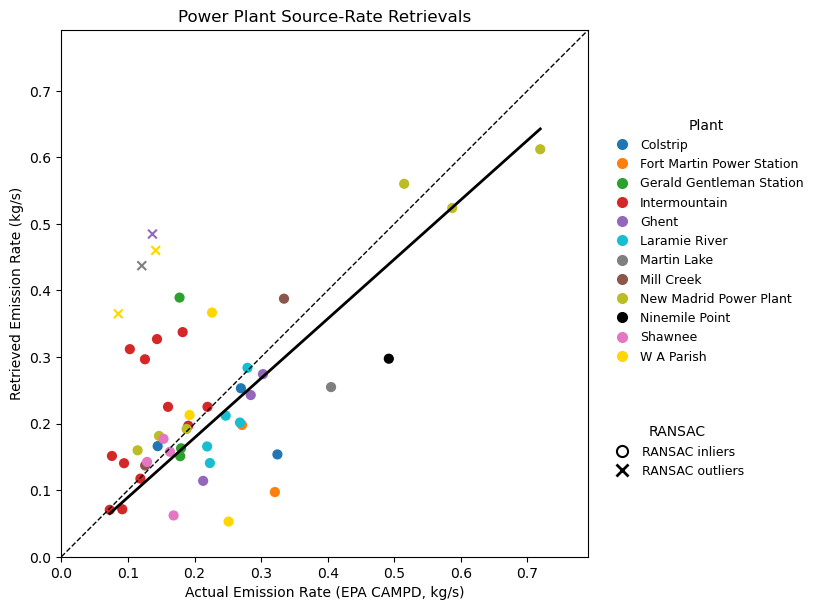

ALL:
Bias (y−x): 0.02
RMSE (vs 1:1): 0.13
NRMSE: 59.64%
MAE: 0.09

RANSAC INLIERS:
Bias (y−x): -0.01
RMSE (vs 1:1): 0.10
NRMSE: 43.68%
MAE: 0.07


In [11]:
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression
import matplotlib.lines as mlines

# inputs
x = plot_df["CAMPD_RATE"].to_numpy(dtype=float) #* plot_df["AMF"].to_numpy(dtype=float)/1.4
y = 1*(plot_df["SMOOTHED"].to_numpy(dtype=float))
            # + plot_df['MEAN'].to_numpy(dtype=float))
c = np.array([colormap_loc[k] for k in plot_df["LOC_NAME"]])
# reshape for sklearn
X = x.reshape(-1, 1)

# RANSAC with linear model
ransac = RANSACRegressor(
    estimator=LinearRegression(fit_intercept=False),
    min_samples=max(3, int(0.6 * len(x))),  # robust default
    residual_threshold=2*np.nanstd(y-x),                # auto (MAD-based)
    random_state=42
)

ransac.fit(X,y)

# extract results
inlier_mask  = ransac.inlier_mask_
outlier_mask = ~inlier_mask

slope = ransac.estimator_.coef_[0]
intercept = ransac.estimator_.intercept_

print(f"RANSAC fit: y = {slope:.3f} x + {intercept:.3f}")
print(f"Inliers: {inlier_mask.sum()} / {len(x)}")

# fitted line for plotting
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
y_fit = slope * x_fit + intercept

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

plt.scatter(x[inlier_mask], y[inlier_mask], s=40, c=c[inlier_mask])
plt.scatter(x[outlier_mask], y[outlier_mask], s=40, c=c[outlier_mask], marker='x')

# for loc_name in colormap_loc.keys():
#     plt.scatter([],[],c=colormap_loc[loc_name], label=loc_name)
# plt.scatter([],[],marker='x', c='k', label='RANSAC outliers')
# plt.scatter([],[],c='k', label='RANSAC inliers')

# --- Legend 1: plants (color only) ---
plant_handles = [
    mlines.Line2D([], [], linestyle='None', marker='o', markersize=8,
                  markerfacecolor=colormap_loc[name], markeredgecolor='none',
                  label=name.replace('_',' '))
    for name in colormap_loc.keys()
]

leg1 = ax.legend(
    handles=plant_handles,
    frameon=False,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.60),
    title="Plant",
    title_fontsize=10,
    handletextpad=0.4
)
ax.add_artist(leg1)  # keep this legend when adding the second

# --- Legend 2: inlier/outlier (shape only) ---
status_handles = [
    mlines.Line2D([], [], linestyle='None', marker='o', markersize=8,
                  markerfacecolor='none', markeredgecolor='k', markeredgewidth=1.5,
                  label='RANSAC inliers'),
    mlines.Line2D([], [], linestyle='None', marker='x', markersize=9,
                  color='k', markeredgewidth=2,
                  label='RANSAC outliers'),
]

ax.legend(
    handles=status_handles,
    frameon=False,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.20),
    title="RANSAC",
    title_fontsize=10,
    handletextpad=0.6
)

plt.plot(x_fit, y_fit, "k-", lw=2, label="RANSAC fit")
# 1:1 line
lims = [0, max(np.nanmax(x), np.nanmax(y)) * 1.1]
ax.plot(lims, lims, 'k--', lw=1)

ax.set_xlabel("Actual Emission Rate (EPA CAMPD, kg/s)")
ax.set_ylabel("Retrieved Emission Rate (kg/s)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.title(f'Power Plant Source-Rate Retrievals')

plt.show()

resid = y - x
bias = np.nanmean(resid)
rmse = np.sqrt(np.nanmean(resid**2))
nrmse = rmse / np.nanmean(x)
mae = np.nanmean(np.abs(resid))

print(f"ALL:")
print(f"Bias (y−x): {bias:.2f}")
print(f"RMSE (vs 1:1): {rmse:.2f}")
print(f"NRMSE: {nrmse:.2%}")
print(f"MAE: {mae:.2f}")

resid = y[inlier_mask] - x[inlier_mask]
bias = np.nanmean(resid)
rmse = np.sqrt(np.nanmean(resid**2))
nrmse = rmse / np.nanmean(x[inlier_mask])
mae = np.nanmean(np.abs(resid))

print(f"\nRANSAC INLIERS:")
print(f"Bias (y−x): {bias:.2f}")
print(f"RMSE (vs 1:1): {rmse:.2f}")
print(f"NRMSE: {nrmse:.2%}")
print(f"MAE: {mae:.2f}")

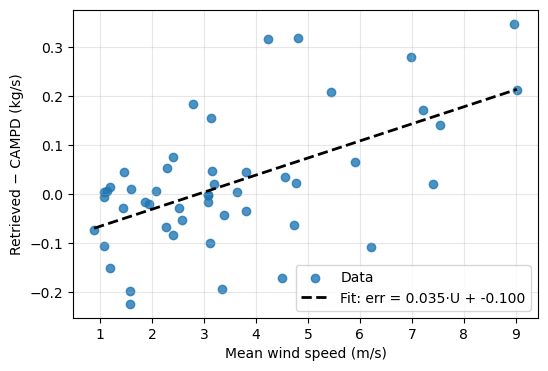

In [50]:
spd_cols = ['HRRR_AGL_SPD', 'HRRR_10M_SPD', 'GEOSFP_50M_SPD']
U_mean = plot_df[spd_cols].mean(axis=1).to_numpy(float)
U_cv = (plot_df[spd_cols].std(axis=1) /
        plot_df[spd_cols].mean(axis=1)).to_numpy(float)


err = y - x

# linear least-squares fit: err = a * U_mean + b
m, b = np.polyfit(U_mean, err, 1)

# fit line for plotting
u_fit = np.linspace(U_mean.min(), U_mean.max(), 200)
err_fit = m * u_fit + b

plt.figure(figsize=(6,4))
plt.scatter(U_mean, err, alpha=0.8, label="Data")
plt.plot(u_fit, err_fit, 'k--', lw=2,
         label=f"Fit: err = {m:.3f}·U + {b:.3f}")

plt.xlabel("Mean wind speed (m/s)")
plt.ylabel("Retrieved − CAMPD (kg/s)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

RANSAC fit: y = 0.847 x + 0.000
Inliers: 47 / 49


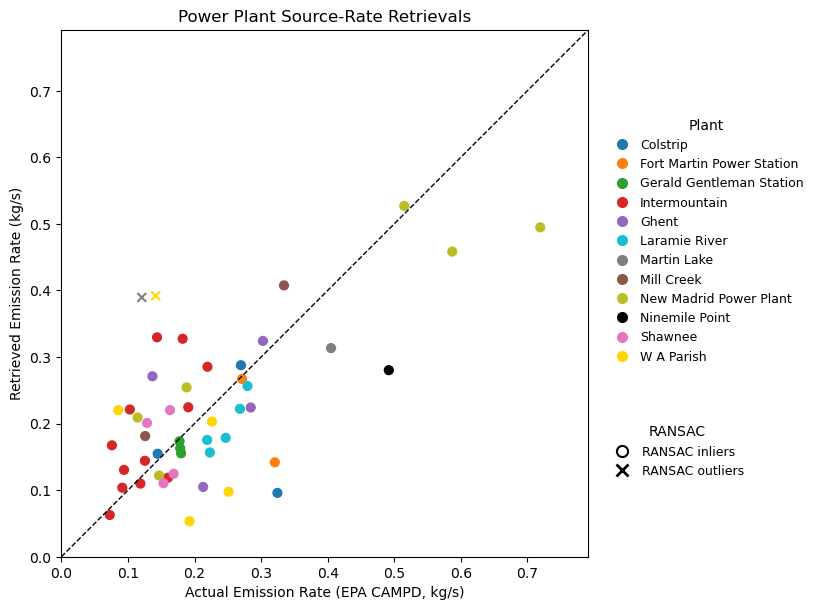

ALL:
Bias (y−x): -0.00
RMSE (vs 1:1): 0.11
NRMSE: 48.66%
MAE: 0.08

RANSAC INLIERS:
Bias (y−x): -0.01
RMSE (vs 1:1): 0.10
NRMSE: 42.69%
MAE: 0.07


In [51]:
import numpy as np
from sklearn.linear_model import RANSACRegressor, LinearRegression
import matplotlib.lines as mlines

# inputs
spd_cols = ['HRRR_AGL_SPD', 'HRRR_10M_SPD', 'GEOSFP_50M_SPD']
U_mean = plot_df[spd_cols].mean(axis=1).to_numpy(float)
wind_corr = 0.035*U_mean-0.1

x = plot_df["CAMPD_RATE"].to_numpy(dtype=float) #* plot_df["AMF"].to_numpy(dtype=float)/1.4
y = 1*(plot_df["SMOOTHED"].to_numpy(dtype=float))
            # + plot_df['MEAN'].to_numpy(dtype=float))

y -= wind_corr
c = np.array([colormap_loc[k] for k in plot_df["LOC_NAME"]])
# reshape for sklearn
X = x.reshape(-1, 1)

# RANSAC with linear model
ransac = RANSACRegressor(
    estimator=LinearRegression(fit_intercept=False),
    min_samples=max(3, int(0.6 * len(x))),  # robust default
    residual_threshold=2*np.nanstd(y-x),                # auto (MAD-based)
    random_state=42
)

ransac.fit(X,y)

# extract results
inlier_mask  = ransac.inlier_mask_
outlier_mask = ~inlier_mask

slope = ransac.estimator_.coef_[0]
intercept = ransac.estimator_.intercept_

print(f"RANSAC fit: y = {slope:.3f} x + {intercept:.3f}")
print(f"Inliers: {inlier_mask.sum()} / {len(x)}")

# fitted line for plotting
x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 200)
y_fit = slope * x_fit + intercept

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

plt.scatter(x[inlier_mask], y[inlier_mask], s=40, c=c[inlier_mask])
plt.scatter(x[outlier_mask], y[outlier_mask], s=40, c=c[outlier_mask], marker='x')

# for loc_name in colormap_loc.keys():
#     plt.scatter([],[],c=colormap_loc[loc_name], label=loc_name)
# plt.scatter([],[],marker='x', c='k', label='RANSAC outliers')
# plt.scatter([],[],c='k', label='RANSAC inliers')

# --- Legend 1: plants (color only) ---
plant_handles = [
    mlines.Line2D([], [], linestyle='None', marker='o', markersize=8,
                  markerfacecolor=colormap_loc[name], markeredgecolor='none',
                  label=name.replace('_',' '))
    for name in colormap_loc.keys()
]

leg1 = ax.legend(
    handles=plant_handles,
    frameon=False,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.60),
    title="Plant",
    title_fontsize=10,
    handletextpad=0.4
)
ax.add_artist(leg1)  # keep this legend when adding the second

# --- Legend 2: inlier/outlier (shape only) ---
status_handles = [
    mlines.Line2D([], [], linestyle='None', marker='o', markersize=8,
                  markerfacecolor='none', markeredgecolor='k', markeredgewidth=1.5,
                  label='RANSAC inliers'),
    mlines.Line2D([], [], linestyle='None', marker='x', markersize=9,
                  color='k', markeredgewidth=2,
                  label='RANSAC outliers'),
]

ax.legend(
    handles=status_handles,
    frameon=False,
    fontsize=9,
    loc="center left",
    bbox_to_anchor=(1.02, 0.20),
    title="RANSAC",
    title_fontsize=10,
    handletextpad=0.6
)

# plt.plot(x_fit, y_fit, "k-", lw=2, label="RANSAC fit")
# 1:1 line
lims = [0, max(np.nanmax(x), np.nanmax(y)) * 1.1]
ax.plot(lims, lims, 'k--', lw=1)

ax.set_xlabel("Actual Emission Rate (EPA CAMPD, kg/s)")
ax.set_ylabel("Retrieved Emission Rate (kg/s)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")

# # smaller legend (from your last request)
# ax.legend(
#     frameon=False,
#     fontsize=9,
#     handlelength=1.2,
#     handletextpad=0.4,
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5)
# )

plt.tight_layout()
plt.title(f'Power Plant Source-Rate Retrievals')

plt.show()

resid = y - x
bias = np.nanmean(resid)
rmse = np.sqrt(np.nanmean(resid**2))
nrmse = rmse / np.nanmean(x)
mae = np.nanmean(np.abs(resid))

print(f"ALL:")
print(f"Bias (y−x): {bias:.2f}")
print(f"RMSE (vs 1:1): {rmse:.2f}")
print(f"NRMSE: {nrmse:.2%}")
print(f"MAE: {mae:.2f}")

resid = y[inlier_mask] - x[inlier_mask]
bias = np.nanmean(resid)
rmse = np.sqrt(np.nanmean(resid**2))
nrmse = rmse / np.nanmean(x[inlier_mask])
mae = np.nanmean(np.abs(resid))

print(f"\nRANSAC INLIERS:")
print(f"Bias (y−x): {bias:.2f}")
print(f"RMSE (vs 1:1): {rmse:.2f}")
print(f"NRMSE: {nrmse:.2%}")
print(f"MAE: {mae:.2f}")

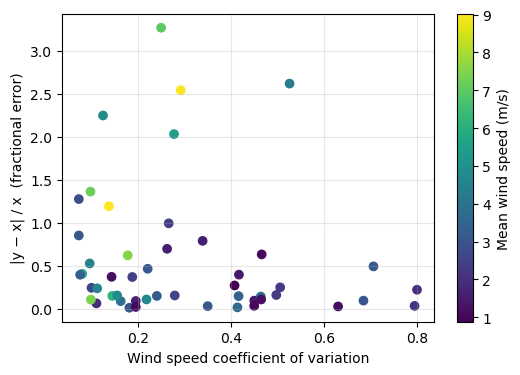

In [42]:
err_abs = np.abs(y - x)
err_rel = err_abs / np.clip(x, 1e-6, None)

plt.figure(figsize=(6,4))
plt.scatter(U_cv, err_rel, c=U_mean)
plt.colorbar(label="Mean wind speed (m/s)")
plt.xlabel("Wind speed coefficient of variation")
plt.ylabel("|y − x| / x  (fractional error)")
plt.grid(alpha=0.3)


In [39]:
amf_act = plot_df['SMOOTHED'] * plot_df['AMF'] / plot_df['CAMPD']
np.mean(np.abs(amf_act - plot_df['AMF']))#/plot_df['AMF'])

0.7006542925056667

In [39]:
np.mean(plot_df['AMF'])

1.457708156881731

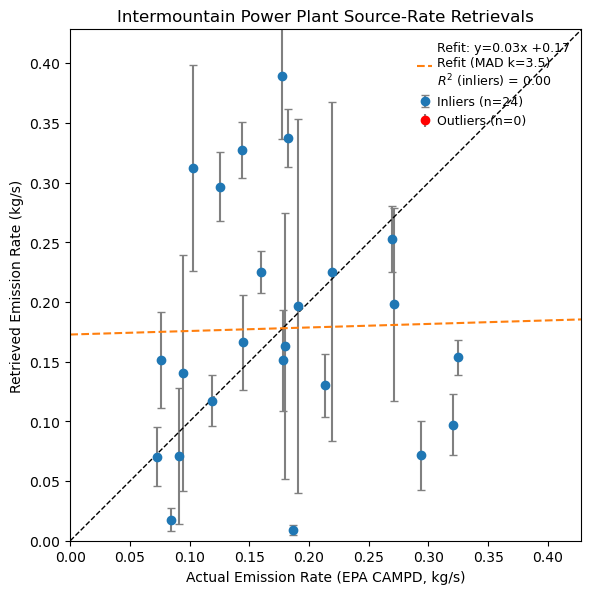

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# # plume-only per-loc table (has winds + CAMPD_RATE, etc.)
# df_loc = data_for_loc.loc[data_for_loc["PLUME"] == True].copy()

# # retrieval log table (has GRANULE + retrieval outputs you want on y-axis)
# retr_log = pd.read_csv(retrieval_log_fn).copy()

# # If retr_log has no LOC_NAME column, this merge is still fine for a single location,
# # but if you ever concatenate multiple locations, add LOC_NAME to retr_log (recommended).
# plot_df = df_loc.merge(
#     retr_log,
#     on="GRANULE",
#     how="inner",
#     validate="one_to_one"  # change to "many_to_one" if retr_log has unique GRANULE but df_loc doesn't
# )

# Truth (x)
x = plot_df["CAMPD_RATE"].to_numpy(dtype=float)

# Retrieved variants (per-granule)
retr_cols = ["SMOOTHED", "MEAN"]
R = plot_df[retr_cols].to_numpy(dtype=float)  # shape (N, 3)

# Choose what you plot as the central retrieved value:
# Option A (common): plot MEAN
y = plot_df["SMOOTHED"].to_numpy(dtype=float)

# Option B: plot average of the 3 (often nice if you’re treating them as an ensemble)
# y = np.nanmean(R, axis=1)

# Processing / retrieval spread (additive)
sigma_proc = np.nanstd(R, axis=1, ddof=1)  # per-granule

# Wind variants (per-granule)
wind_cols = ["HRRR_AGL_SPD", "HRRR_10M_SPD", "GEOSFP_50M_SPD"]
W = plot_df[wind_cols].to_numpy(dtype=float)

U = np.nanmean(W, axis=1)
sigma_U = np.nanstd(W, axis=1, ddof=1)

# sigma_U = np.sqrt((0.1*plot_df["HRRR_AGL_SPD"])**2+1**2)

# Total y-uncertainty: sqrt( proc^2 + (E * sigma_U/U)^2 )
sigma_y = np.full_like(y, np.nan, dtype=float)

ok = np.isfinite(x) & np.isfinite(y) & np.isfinite(sigma_proc) & np.isfinite(U) & np.isfinite(sigma_U) & (U > 0)
sigma_y[ok] = np.sqrt(
    sigma_proc[ok]**2 +
    (y[ok] * (sigma_U[ok] / U[ok]))**2
)

# --- Use only valid points ---
xx = x[ok]
yy = y[ok]
yyerr = y[ok]*sigma_U[ok]/U[ok] # sigma_y[ok]

# ---------- Robust outlier detection (MAD on residuals) ----------
# Initial fit
m0, b0 = np.polyfit(xx, yy, 1)
res0 = yy - (m0 * xx + b0)

# Robust scale via MAD
mad = np.median(np.abs(res0 - np.median(res0)))
robust_sigma = 1.4826 * mad  # ~= std if residuals are normal-ish

# Fallback if MAD is zero (e.g., tiny dataset or identical points)
if not np.isfinite(robust_sigma) or robust_sigma == 0:
    robust_sigma = np.std(res0) if np.std(res0) > 0 else 1.0

# k = 3.5  # outlier threshold (3.5 is common; 3.0 is stricter)
k=3.5
inlier = np.abs(res0) <= k * robust_sigma
outlier = ~inlier

# Refit on inliers only
m, b = np.polyfit(xx[inlier], yy[inlier], 1)

# R^2 on inliers (more meaningful once you’ve clipped)
r = np.corrcoef(xx[inlier], yy[inlier])[0, 1]
r2_in = float(r**2) if np.isfinite(r) else np.nan

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 6))

# Inliers (default color)
ax.errorbar(
    xx[inlier], yy[inlier],
    yerr=yyerr[inlier],
    fmt='o', capsize=3, elinewidth=1.5, ecolor='0.5',
    label=f"Inliers (n={inlier.sum()})"
)

# Outliers (red)
ax.errorbar(
    xx[outlier], yy[outlier],
    yerr=yyerr[outlier],
    fmt='o', capsize=3, elinewidth=1.5, ecolor='0.5',
    color='red',
    label=f"Outliers (n={outlier.sum()})"
)

# 1:1 line
lims = [0, max(np.nanmax(xx), np.nanmax(yy)) * 1.1]
ax.plot(lims, lims, 'k--', lw=1)

# Refit line (inliers)
grid = np.linspace(lims[0], lims[1], 200)
ax.plot(grid, m*grid + b, '--', lw=1.5, label=f"Refit: y={m:.2f}x {b:+.2f}\nRefit (MAD k={k})\n$R^2$ (inliers) = {r2_in:.2f}")


ax.set_xlabel("Actual Emission Rate (EPA CAMPD, kg/s)")
ax.set_ylabel("Retrieved Emission Rate (kg/s)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect("equal", adjustable="box")

# smaller legend (from your last request)
ax.legend(frameon=False, fontsize=9, handlelength=1.2, handletextpad=0.4)

plt.tight_layout()
plt.title(f'{loc_name} Power Plant Source-Rate Retrievals')

plt.show()

NameError: name 'xx' is not defined

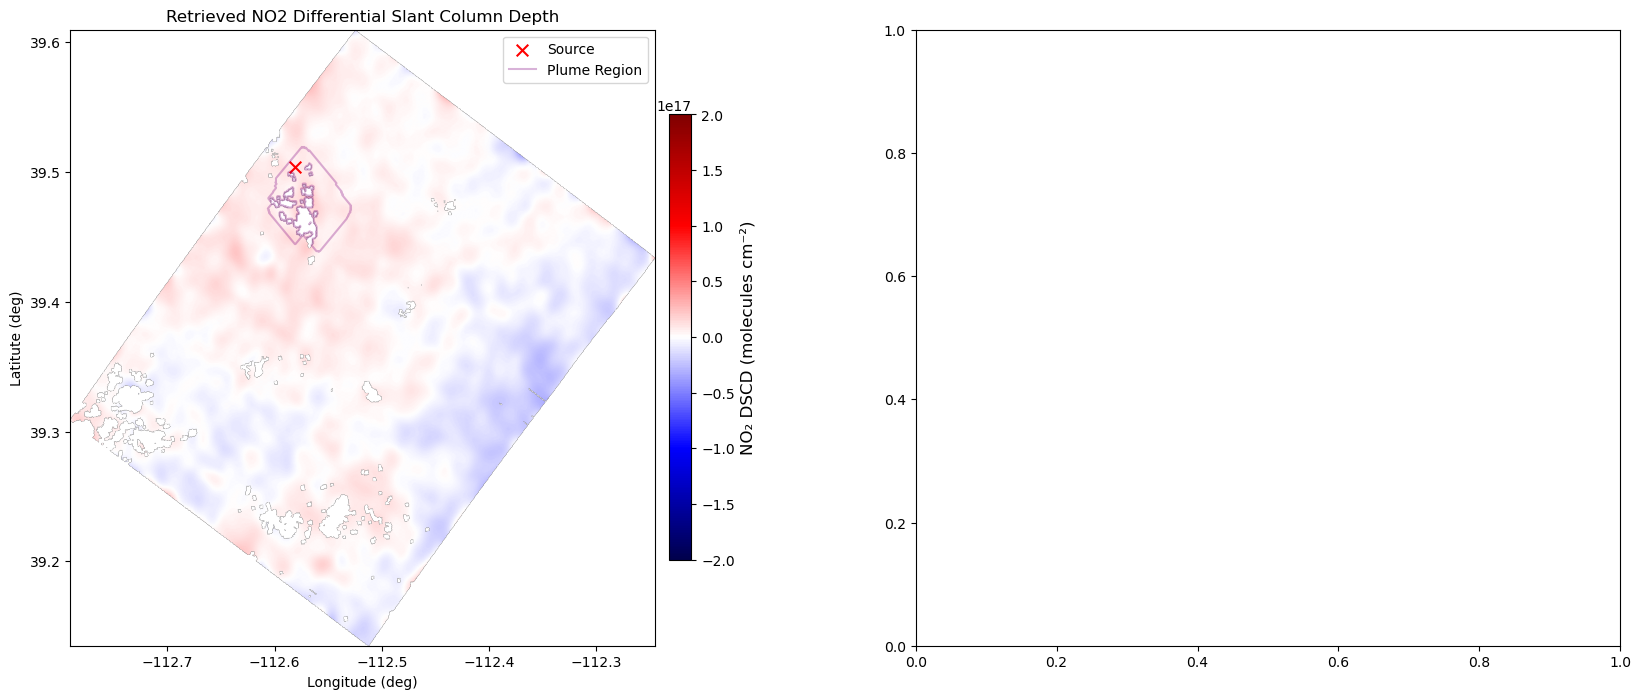

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20,8))

plot_img = tv*1e19
# plot_img = dSCD_nan

im = ax[0].imshow(plot_img, cmap='seismic', origin='upper', 
              aspect='auto', vmin=-2e17, vmax=2e17, extent=bounds)
# cb = fig.colorbar(im, ax=ax[0])

cb = fig.colorbar(im, ax=ax[0], shrink=0.85, pad=0.02)
cb.set_label("NO₂ DSCD (molecules cm⁻²)", fontsize=12)
# shrink height and move it down slightly
cb.ax.set_position([
    cb.ax.get_position().x0,          # same left
    cb.ax.get_position().y0 + 0.05,   # move down a bit
    cb.ax.get_position().width,       # same width
    cb.ax.get_position().height * 0.85  # shrink height (0.85 = 85%)
])
ax[0].scatter([loc_data['LON']], [loc_data['LAT']], marker='x', c='red', s=70, label='Source')
ax[0].contour(~np.isnan(dSCD_plume_masked[:,:]), levels=[0.5], 
            colors='purple', alpha=0.3, linestyle='-', linewidths=1.5,
            extent=[bounds[0], bounds[1], bounds[3], bounds[2]])
ax[0].plot([], color='purple', alpha=0.3, label='Plume Region')
ax[0].legend()
ax[0].set_title("Retrieved NO2 Differential Slant Column Depth")
ax[0].set_xlabel("Longitude (deg)")
ax[0].set_ylabel("Latitute (deg)")

ax[0].set_xlim(lonmin_bnd, lonmax_bnd)
ax[0].set_ylim(latmin_bnd, latmax_bnd)



# Inliers (default color)
ax[1].errorbar(
    xx[inlier], yy[inlier],
    yerr=yyerr[inlier],
    fmt='o', capsize=3, elinewidth=1.5, ecolor='0.5',
    label=f"Inliers (n={inlier.sum()})"
)

# Outliers (red)
ax[1].errorbar(
    xx[outlier], yy[outlier],
    yerr=yyerr[outlier],
    fmt='o', capsize=3, elinewidth=1.5, ecolor='0.5',
    color='red',
    label=f"Outliers (n={outlier.sum()})"
)

# 1:1 line
lims = [0, max(np.nanmax(xx), np.nanmax(yy)) * 1.1]
ax[1].plot(lims, lims, 'k--', lw=1)

# Refit line (inliers)
grid = np.linspace(lims[0], lims[1], 200)
ax[1].plot(grid, m*grid + b, '--', lw=1.5, label=f"Refit: y={m:.2f}x {b:+.2f}\nRefit (MAD k={k})\n$R^2$ (inliers) = {r2_in:.2f}")


ax[1].set_xlabel("Actual Emission Rate (EPA CAMPD, kg/s)")
ax[1].set_ylabel("Retrieved Emission Rate (kg/s)")
ax[1].set_xlim(lims); ax[1].set_ylim(lims)
ax[1].set_aspect("equal", adjustable="box")

# smaller legend (from your last request)
ax[1].legend(frameon=False, fontsize=9, handlelength=1.2, handletextpad=0.4)

plt.tight_layout()
plt.title(f'{loc_name} Power Plant Source-Rate Retrievals')

plt.show()

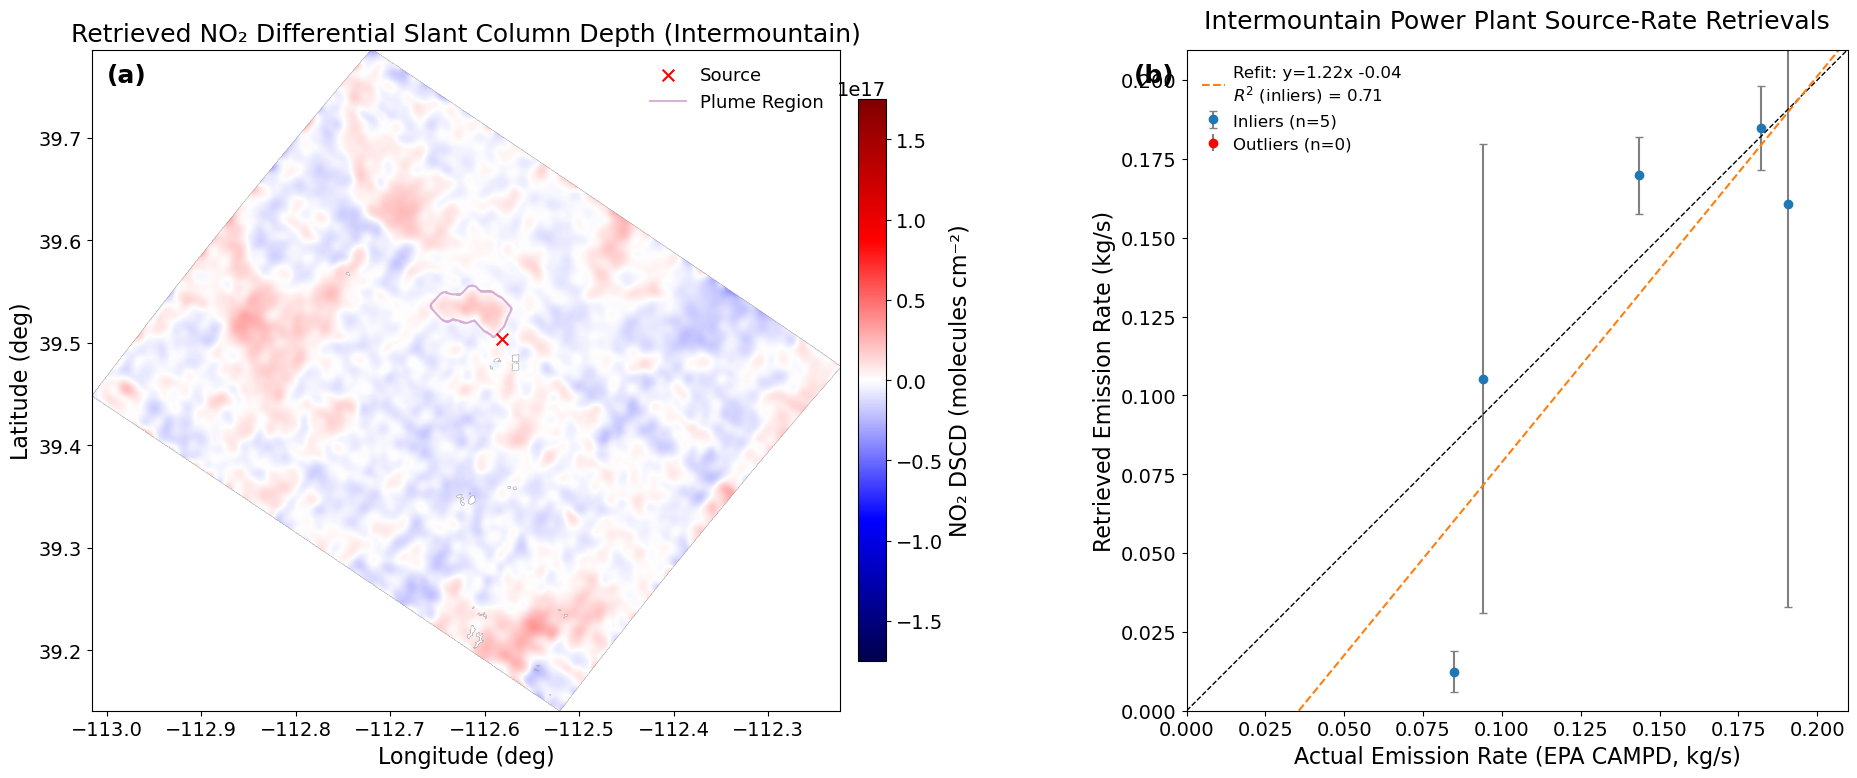

In [17]:
# =========================
# Global font scaling
# =========================
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 20,
})

# =========================
# Figure + axes
# =========================
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8), layout='tight')

# =========================
# Panel (a): Map
# =========================
plot_img = tv * 1e19

im = ax[0].imshow(
    plot_img,
    cmap="seismic",
    origin="upper",
    aspect="auto",
    vmin=-1.75e17,
    vmax=1.75e17,
    extent=bounds
)

cb = fig.colorbar(im, ax=ax[0], shrink=0.85, pad=0.02)
cb.set_label("NO₂ DSCD (molecules cm⁻²)", fontsize=16)
cb.ax.tick_params(labelsize=14)

# shrink + lower colorbar slightly
cb.ax.set_position([
    cb.ax.get_position().x0,
    cb.ax.get_position().y0 + 0.05,
    cb.ax.get_position().width,
    cb.ax.get_position().height * 0.85
])

ax[0].scatter(
    [loc_data["LON"]], [loc_data["LAT"]],
    marker="x", c="red", s=70, label="Source"
)

ax[0].contour(
    ~np.isnan(dSCD_plume_masked[:, :]),
    levels=[0.5],
    colors="purple",
    alpha=0.3,
    linewidths=1.5,
    extent=[bounds[0], bounds[1], bounds[3], bounds[2]]
)

ax[0].plot([], color="purple", alpha=0.3, label="Plume Region")
ax[0].legend(frameon=False)

ax[0].set_title("Retrieved NO₂ Differential Slant Column Depth (Intermountain)")
ax[0].set_xlabel("Longitude (deg)")
ax[0].set_ylabel("Latitude (deg)")
ax[0].set_xlim(lonmin_bnd, lonmax_bnd)
ax[0].set_ylim(latmin_bnd, latmax_bnd)

# (a) label
ax[0].text(
    0.02, 0.98, "(a)",
    transform=ax[0].transAxes,
    fontsize=18,
    fontweight="bold",
    va="top", ha="left"
)

# =========================
# Panel (b): Scatter + fit
# =========================
ax[1].errorbar(
    xx[inlier], yy[inlier],
    yerr=yyerr[inlier],
    fmt="o",
    capsize=3,
    elinewidth=1.5,
    ecolor="0.5",
    label=f"Inliers (n={inlier.sum()})"
)

ax[1].errorbar(
    xx[outlier], yy[outlier],
    yerr=yyerr[outlier],
    fmt="o",
    capsize=3,
    elinewidth=1.5,
    ecolor="0.5",
    color="red",
    label=f"Outliers (n={outlier.sum()})"
)

lims = [0, max(np.nanmax(xx), np.nanmax(yy)) * 1.1]
ax[1].plot(lims, lims, "k--", lw=1)

grid = np.linspace(lims[0], lims[1], 200)
ax[1].plot(
    grid, m * grid + b,
    "--", lw=1.5,
    label=(
        f"Refit: y={m:.2f}x {b:+.2f}\n"
        f"$R^2$ (inliers) = {r2_in:.2f}"
    )
)

ax[1].set_xlabel("Actual Emission Rate (EPA CAMPD, kg/s)")
ax[1].set_ylabel("Retrieved Emission Rate (kg/s)")
ax[1].set_xlim(lims)
ax[1].set_ylim(lims)
ax[1].set_aspect("equal", adjustable="box")

ax[1].legend(
    frameon=False,
    fontsize=12,
    handlelength=1.4,
    handletextpad=0.5
)

# (b) label
ax[1].text(
    -0.08, 0.98, "(b)",
    transform=ax[1].transAxes,
    fontsize=18,
    fontweight="bold",
    va="top", ha="left"
)

# =========================
# Final layout
# =========================
ax[1].set_title(f"{loc_name} Power Plant Source-Rate Retrievals", y=1.02)
# plt.tight_layout()
plt.show()
